# Network Analysis of the Global Airport Transportation System

**Author:** Iker Lomas Javaloyes  
**Email:** ikerlomas@ifisc.uib-csic.es  
**Date:** November 2025

---

## Project overview

This notebook presents the analysis of the global airport transportation network using data from OpenFlights. The goal is to study the structural properties of the network of airports and flight routes around the world. The focus will be on:

- Describing the basic topology of the network,
- Computing key network metrics (clustering, centralities, communities),
- Understanding the connectivity and main hubs of the system,
- Visualizing the network and its underlying community structure.

---

## Required Libraries

We begin importing the essential libraries for data processing, network analysis, and visualization.



In [1]:
import pandas as pd # For data handling
import networkx as nx # For building and analyzing networks
import matplotlib.pyplot as plt # For plotting and visualization
import seaborn as sns # For enhanced data visualization
import community as community_louvain # For community detection (Louvain method)
import os # For file path handling
import cartopy.crs as ccrs # For cartographic projections
import cartopy.feature as cfeature # For cartographic features
import plotly.graph_objects as go # For interactive visualizations
import numpy as np # For numerical operations
from scipy import stats
from scipy.optimize import curve_fit # For curve fitting

In [2]:
# Configuración global para usar LaTeX en todas las gráficas con Computer Modern
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['font.serif'] = ['Computer Modern']  # Especifica Computer Modern para LaTeX
plt.rc('font', size=14)  # Ajusta el tamaño de la fuente según prefieras 18
plt.rcParams['grid.linestyle'] = '--'  # Estilo de línea del grid
plt.rcParams['grid.linewidth'] = 0.4   # Ancho de línea del grid
plt.rcParams['grid.alpha'] = 0.6       # Transparencia del grid
plt.rcParams['axes.grid'] = True       # Activa el grid de manera predeterminada en todos los ejes
plt.rcParams['legend.frameon'] = True  # Mostrar el marco de la leyenda
plt.rcParams['legend.fancybox'] = False  # Sin esquinas redondeadas
plt.rcParams['legend.shadow'] = True  # Con sombra
plt.rcParams['legend.edgecolor'] = 'black'  # Color del borde negro


---

## Loading the data

We'll load the processed HDF5 files containing the airports and routes data and use them to reconstruct the network Network.


In [3]:
# Load processed data and reconstruct the network graph
# Define paths to processed data files
processed_data_dir = "../data/processed"
airports_path = os.path.join(processed_data_dir, "airports_processed.h5")
routes_path = os.path.join(processed_data_dir, "routes_processed.h5")

# Load airports and routes data
airports_df = pd.read_hdf(airports_path, key='nodes')
routes_df = pd.read_hdf(routes_path, key='edges')

print(f"Loaded {len(airports_df)} airports and {len(routes_df)} routes.")

# Rebuild the network graph from loaded data
G = nx.Graph()

# Add nodes with attributes
for idx, row in airports_df.iterrows():
    G.add_node(idx, **row.to_dict())

# Add edges from routes
edges = list(routes_df.itertuples(index=False, name=None))
G.add_edges_from(edges)

print(f"Network constructed with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")


Loaded 3195 airports and 19054 routes.
Network constructed with 3304 nodes and 19054 edges.


In [4]:
# Remover nodos sin atributos de aeropuerto
nodes_to_remove = [node for node in G.nodes() if 'name' not in G.nodes[node]]
G.remove_nodes_from(nodes_to_remove)

print(f"Clen Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Clen Network: 3195 nodes, 18835 edges



---
## Visualizing the Airport Network

Valid nodes with coordinates: 3195 out of 3195


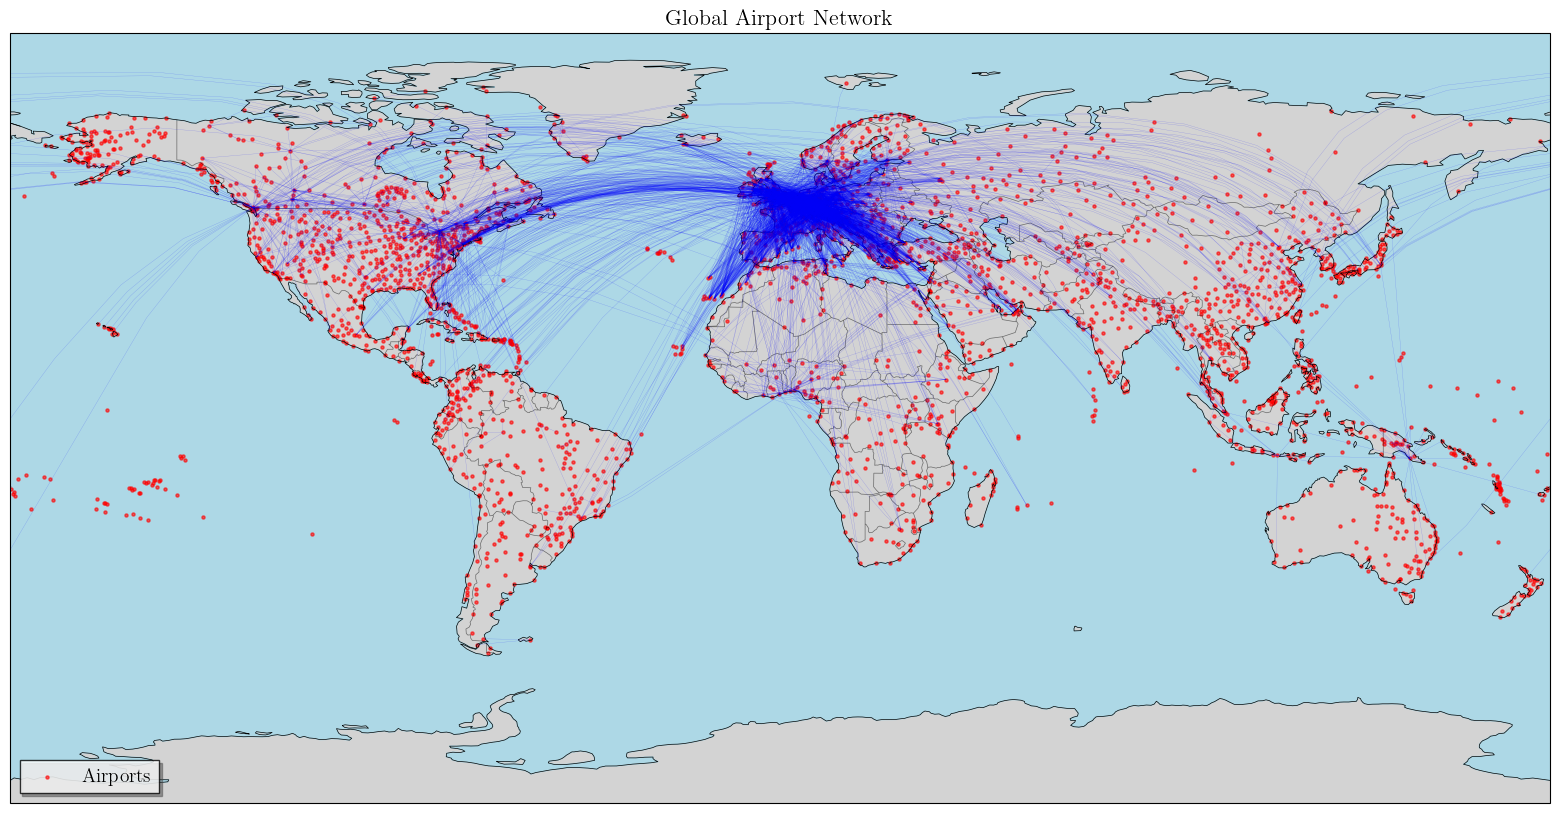

In [5]:
# Extract coordinates from node attributes, filtering nodes without coordinates
lats = []
lons = []
valid_nodes = []

for node in G.nodes():
    if 'lat' in G.nodes[node] and 'lon' in G.nodes[node]:
        lat = G.nodes[node]['lat']
        lon = G.nodes[node]['lon']
        # Check if coordinates are valid (not NaN or None)
        if lat is not None and lon is not None and not (pd.isna(lat) or pd.isna(lon)):
            lats.append(lat)
            lons.append(lon)
            valid_nodes.append(node)

print(f"Valid nodes with coordinates: {len(valid_nodes)} out of {G.number_of_nodes()}")

# Create figure with map projection
fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5)

# Plot airports as points
ax.scatter(lons, lats, s=5, c='red', alpha=0.6, transform=ccrs.PlateCarree(), 
           label='Airports')

# Plot routes as lines (sample subset to avoid overcrowding)
# Only plot routes between valid nodes
edge_sample = [e for e in list(G.edges())[:5000] if e[0] in valid_nodes and e[1] in valid_nodes]

for src, dst in edge_sample:
    src_lon, src_lat = G.nodes[src]['lon'], G.nodes[src]['lat']
    dst_lon, dst_lat = G.nodes[dst]['lon'], G.nodes[dst]['lat']
    ax.plot([src_lon, dst_lon], [src_lat, dst_lat], 
            color='blue', linewidth=0.2, alpha=0.3, transform=ccrs.Geodetic())

ax.set_global()
plt.title('Global Airport Network', fontsize=16)
plt.legend()
plt.savefig('../results/figures/airport_network.pdf', bbox_inches='tight')
plt.show()

In [6]:
# Extract valid nodes with coordinates
valid_nodes = []
node_info = []

for node in G.nodes():
    if 'lat' in G.nodes[node] and 'lon' in G.nodes[node]:
        lat = G.nodes[node]['lat']
        lon = G.nodes[node]['lon']
        if lat is not None and lon is not None and not (pd.isna(lat) or pd.isna(lon)):
            valid_nodes.append(node)
            name = G.nodes[node].get('name', 'Unknown')
            city = G.nodes[node].get('city', 'Unknown')
            country = G.nodes[node].get('country', 'Unknown')
            iata = G.nodes[node].get('IATA', 'N/A')
            node_info.append({
                'node': node,
                'lat': lat,
                'lon': lon,
                'name': name,
                'city': city,
                'country': country,
                'iata': iata,
                'degree': G.degree(node)
            })

nodes_df = pd.DataFrame(node_info)
print(f"Valid nodes with coordinates: {len(valid_nodes)} out of {G.number_of_nodes()}")

# Sample edges for visualization
edge_sample = [e for e in list(G.edges()) if e[0] in valid_nodes and e[1] in valid_nodes]
print(f"Plotting {len(edge_sample)} routes")

# Create single trace for all edges (OPTIMIZED)
edge_lons = []
edge_lats = []

for src, dst in edge_sample:
    src_lat = G.nodes[src]['lat']
    src_lon = G.nodes[src]['lon']
    dst_lat = G.nodes[dst]['lat']
    dst_lon = G.nodes[dst]['lon']
    
    edge_lons.extend([src_lon, dst_lon, None])  # None creates gap between lines
    edge_lats.extend([src_lat, dst_lat, None])

edge_trace = go.Scattergeo(
    lon=edge_lons,
    lat=edge_lats,
    mode='lines',
    line=dict(width=0.3, color='rgba(100, 150, 200, 0.2)'),
    hoverinfo='none',
    showlegend=False
)

# Create node trace (airports)
node_trace = go.Scattergeo(
    lon=nodes_df['lon'],
    lat=nodes_df['lat'],
    mode='markers',
    marker=dict(
        size=nodes_df['degree'] / 5,  # Size proportional to degree
        color=nodes_df['degree'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Degree"),
        line=dict(width=0.5, color='white')
    ),
    text=nodes_df.apply(lambda row: f"{row['name']}<br>{row['city']}, {row['country']}<br>IATA: {row['iata']}<br>Connections: {row['degree']}", axis=1),
    hoverinfo='text',
    name='Airports'
)

# Create figure with optimized traces
fig = go.Figure(data=[edge_trace, node_trace])

# Update layout
fig.update_layout(
    title={
        'text': 'Interactive Global Airport Network',
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 20}
    },
    showlegend=False,
    geo=dict(
        projection_type='natural earth',
        showland=True,
        landcolor='rgb(243, 243, 243)',
        coastlinecolor='rgb(204, 204, 204)',
        showocean=True,
        oceancolor='rgb(230, 245, 255)',
        showcountries=True,
        countrycolor='rgb(204, 204, 204)'
    ),
    height=700,
    width=1400
)

# Save as HTML
fig.write_html("../results/figures/airport_network_interactive.html")
fig.write_image("../results/figures/airport_network_interactive.pdf", width=1400, height=700)
print("Interactive map saved as 'airport_network_interactive.html' and 'airport_network.pdf'")

# Show in notebook
fig.show()

Valid nodes with coordinates: 3195 out of 3195
Plotting 18835 routes
Interactive map saved as 'airport_network_interactive.html' and 'airport_network.pdf'
Interactive map saved as 'airport_network_interactive.html' and 'airport_network.pdf'


In [7]:
# 1. DATA PREPARATION
# ---------------------------------------------------------
valid_nodes = []
node_info = []

# Assuming 'G' exists
for node in G.nodes():
    if 'lat' in G.nodes[node] and 'lon' in G.nodes[node]:
        lat = G.nodes[node]['lat']
        lon = G.nodes[node]['lon']
        if lat is not None and lon is not None and not (pd.isna(lat) or pd.isna(lon)):
            valid_nodes.append(node)
            node_info.append({
                'node': node,
                'lat': lat,
                'lon': lon,
                'name': G.nodes[node].get('name', 'Unknown'),
                'city': G.nodes[node].get('city', 'Unknown'),
                'country': G.nodes[node].get('country', 'Unknown'),
                'iata': G.nodes[node].get('IATA', 'N/A'),
                'degree': G.degree(node)
            })

nodes_df = pd.DataFrame(node_info)
edge_sample = [e for e in list(G.edges()) if e[0] in valid_nodes and e[1] in valid_nodes]

print(f"Processing {len(valid_nodes)} airports and {len(edge_sample)} routes...")

edge_lons = []
edge_lats = []
for src, dst in edge_sample:
    src_lat = G.nodes[src]['lat']
    src_lon = G.nodes[src]['lon']
    dst_lat = G.nodes[dst]['lat']
    dst_lon = G.nodes[dst]['lon']
    edge_lons.extend([src_lon, dst_lon, None])
    edge_lats.extend([src_lat, dst_lat, None])

# 2. DEFINITION OF TRACES
# ---------------------------------------------------------

edge_trace = go.Scattergeo(
    lon=edge_lons,
    lat=edge_lats,
    mode='lines',
    line=dict(width=0.2, color='rgba(56, 189, 248, 0.2)'), # Sky-400
    hoverinfo='none',
    showlegend=False
)

node_trace = go.Scattergeo(
    lon=nodes_df['lon'],
    lat=nodes_df['lat'],
    mode='markers',
    marker=dict(
        size=nodes_df['degree'] / 5, 
        color=nodes_df['degree'],
        colorscale='Viridis', 
        showscale=True,
        colorbar=dict(
            title=dict(text="Degree", side="right", font=dict(color="#94a3b8")),
            tickfont=dict(color="#94a3b8"),
            bgcolor="rgba(0,0,0,0)",
            x=0.95
        ),
        line=dict(width=0.5, color='rgba(255,255,255,0.8)')
    ),
    text=nodes_df.apply(lambda row: f"<b>{row['name']}</b> ({row['iata']})<br>{row['city']}, {row['country']}<br>Connections: {row['degree']}", axis=1),
    hoverinfo='text',
    name='Airports'
)

# 3. LAYOUT WITH BUTTONS AND ZOOM/COLOR FIXES
# ---------------------------------------------------------

updatemenus = [
    dict(
        type="buttons",
        direction="left",
        pad={"r": 10, "t": 10},
        showactive=True,
        x=0.05,
        xanchor="left",
        y=1.1, 
        yanchor="top",
        bgcolor="#0f172a", # Slate-900 (Color base del botón)
        bordercolor="#1e293b",
        font=dict(color="#e2e8f0"),
        buttons=[
            dict(
                label="2D Map",
                method="relayout",
                args=[{
                    "geo.projection.type": "natural earth",
                    "geo.projection.rotation": {'lat': 0, 'lon': 0, 'roll': 0},
                    # RESET COMPLETO DEL ZOOM Y CENTRO
                    "geo.center": None, 
                    "geo.lataxis.range": None,
                    "geo.lonaxis.range": None,
                    "geo.fitbounds": "locations" 
                }]
            ),
            dict(
                label="3D Globe",
                method="relayout",
                args=[{
                    "geo.projection.type": "orthographic",
                    "geo.projection.rotation": {'lat': 40, 'lon': -3, 'roll': 0}, # ESPAÑA
                    # RESET COMPLETO DEL ZOOM Y CENTRO
                    "geo.center": None,
                    "geo.lataxis.range": None,
                    "geo.lonaxis.range": None,
                    "geo.fitbounds": "locations"
                }]
            )
        ]
    )
]

fig = go.Figure(data=[edge_trace, node_trace])

fig.update_layout(
    margin={"r":0,"t":0,"l":0,"b":0},
    paper_bgcolor='#020617', 
    plot_bgcolor='#020617',  
    updatemenus=updatemenus, 
    showlegend=False,
    geo=dict(
        projection_type='natural earth', 
        showland=True,
        landcolor='#0f172a',      
        showocean=True,
        oceancolor='#020617',     
        showlakes=True,           
        lakecolor='#020617',      
        showrivers=False,         
        showcountries=True,
        countrycolor='#1e293b',   
        coastlinecolor='#1e293b', 
        showframe=False,          
        bgcolor='#020617',        
        fitbounds="locations"     
    ),
    height=750, 
)

# ---------------------------------------------------------
png_output_path = "../docs/airport_network_interactive.png"
os.makedirs(os.path.dirname(png_output_path), exist_ok=True)

fig.write_image(png_output_path, width=1920, height=1080, scale=2)
print(f"✅ Static PNG image saved at: {png_output_path}")

# Generar solo el DIV
plot_div = fig.to_html(full_html=False, include_plotlyjs='cdn', config={'responsive': True, 'displayModeBar': False})


# 4. TEMPLATE HTML
# ---------------------------------------------------------
html_template = f"""
<!DOCTYPE html>
<html lang="en" class="scroll-smooth">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0"> 
    <title>Interactive Airport Network</title>
    <meta name="description" content="Interactive 3D visualization of the Global Airport Network."> 
    <script src="https://cdn.tailwindcss.com"></script>
    <link rel="icon" href="data:image/svg+xml,<svg xmlns=%22http://www.w3.org/2000/svg%22 viewBox=%220 0 100 100%22><text y=%22.9em%22 font-size=%2290%22>✈️</text></svg>">
    
    <link rel="preconnect" href="https://fonts.googleapis.com"> 
    <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin> 
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;800&family=JetBrains+Mono:wght@400;700&display=swap" rel="stylesheet"> 
    <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.4.0/css/all.min.css"> 

    <script>
        tailwind.config = {{
            theme: {{
                extend: {{
                    fontFamily: {{
                        sans: ['Inter', 'sans-serif'],
                        mono: ['JetBrains Mono', 'monospace'],
                    }},
                    colors: {{
                        bg: '#020617', 
                        surface: '#0f172a',
                        accent: '#38bdf8',
                        accentHover: '#0ea5e9', 
                    }}
                }}
            }}
        }}
    </script>

    <style>
        body {{
            background-color: #020617;
            color: #94a3b8;
        }}
        .plotly-graph-div {{
            margin: auto;
            border-radius: 1rem;
            overflow: hidden;
            border: 1px solid rgba(255, 255, 255, 0.05);
            box-shadow: 0 25px 50px -12px rgba(0, 0, 0, 0.5);
        }}
        
        /* --- CORRECCIÓN DE ESTILO PARA BOTONES PLOTLY --- */
        
        /* Contenedor del grupo de botones */
        .updatemenu-container {{
            border: 1px solid #1e293b !important;
            border-radius: 0.375rem !important; /* rounded-md */
            overflow: hidden;
        }}
        
        /* Botones Inactivos */
        .updatemenu-item rect {{
            fill: #0f172a !important; /* Slate-900 */
        }}
        .updatemenu-item text {{
            fill: #94a3b8 !important; /* Slate-400 */
            font-family: 'Inter', sans-serif !important;
            font-weight: 500 !important;
        }}
        
        /* Botón ACTIVO (El seleccionado) */
        .updatemenu-item-active rect {{
            fill: #38bdf8 !important; /* Accent Color (Cyan) */
            stroke: #38bdf8 !important;
        }}
        .updatemenu-item-active text {{
            fill: #020617 !important; /* Dark Text for contrast */
            font-weight: 700 !important;
        }}
        
        /* Hover effects (opcional, Plotly es un poco rígido con esto en SVG) */
        .updatemenu-item:hover rect {{
            fill: #1e293b !important;
        }}
    </style>
</head>
<body class="antialiased selection:bg-sky-500/30 flex flex-col min-h-screen"> 

    <nav class="fixed w-full z-50 border-b border-white/5 bg-[#020617]/90 backdrop-blur-xl"> 
        <div class="max-w-8xl mx-auto px-4 md:px-6 h-16 flex items-center justify-between"> 
            <div class="font-bold text-lg tracking-tight text-white flex items-center gap-2"> 
                <i class="fa-solid fa-earth-americas text-accent"></i> 
                <span>Network <span class="text-slate-400">Map Visualization</span></span> 
            </div> 
            <div> 
                <a href="index.html" class="text-sm font-medium text-slate-400 hover:text-white transition-colors flex items-center gap-2 px-4 py-2 rounded-lg hover:bg-white/5"> 
                    <i class="fa-solid fa-arrow-left"></i> Back to Home 
                </a> 
            </div> 
        </div> 
    </nav> 

    <main class="flex-grow pt-24 pb-12 container max-w-[95%] mx-auto px-2 md:px-4 flex flex-col items-center"> 
        <div class="text-center mb-8 max-w-2xl mx-auto"> 
            <h1 class="text-3xl md:text-4xl font-bold text-white mb-2">Global Connectivity</h1> 
            <p class="text-slate-400">
                Interactive visualization of {len(valid_nodes)} airports and {len(edge_sample)} routes. 
                <span class="hidden md:inline">Hover over nodes to see details. Switch between 2D and 3D views using the buttons.</span>
            </p> 
        </div> 
        
        <div class="w-full relative z-0">
            {plot_div}
        </div>
    </main> 

    <footer class="border-t border-white/5 bg-[#020617] py-8 text-center text-slate-600 text-xs uppercase tracking-wider font-mono"> 
        <p>&copy; 2025 Global Airport Network Analysis</p> 
    </footer> 
</body>
</html>
"""

# Save HTML to file
output_path = "../docs/airport_network_interactive.html"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with open(output_path, "w", encoding="utf-8") as f:
    f.write(html_template)

print(f"✅ Interactive map saved at: {output_path}")

Processing 3195 airports and 18835 routes...
✅ Static PNG image saved at: ../docs/airport_network_interactive.png
✅ Interactive map saved at: ../docs/airport_network_interactive.html


### Degree for each airport

In [5]:
# Calcular degree para todos los nodos
degrees = dict(G.degree())

# Crear lista para almacenar información de aeropuertos
airport_data = []

for node_id, degree in degrees.items():
    # Obtener atributos del nodo
    node_attrs = G.nodes[node_id]
    
    airport_data.append({
        'airport_id': node_id,
        'name': node_attrs.get('name', 'Unknown'),
        'IATA': node_attrs.get('IATA', 'N/A'),
        'city': node_attrs.get('city', 'Unknown'),
        'country': node_attrs.get('country', 'Unknown'),
        'degree': degree
    })

# Crear DataFrame y ordenar por degree (descendente)
df_airports_by_degree = pd.DataFrame(airport_data)
df_airports_by_degree = df_airports_by_degree.sort_values('degree', ascending=False).reset_index(drop=True)


# Guardar el DataFrame completo si quieres
df_airports_by_degree.to_hdf('../results/tables/airports_ranked_by_degree.h5', key='df', mode='w', index=False)
df_airports_by_degree

,airport_id,name,IATA,city,country,degree
0,580.0,Amsterdam Airport Schiphol,AMS,Amsterdam,Netherlands,248
1,340.0,Frankfurt am Main Airport,FRA,Frankfurt,Germany,244
2,1382.0,Charles de Gaulle International Airport,CDG,Paris,France,240
3,1701.0,Atatürk International Airport,ISL,Istanbul,Turkey,233
4,3682.0,Hartsfield Jackson Atlanta International Airport,ATL,Atlanta,United States,217
...,...,...,...,...,...,...
3190,8217.0,Kegaska Airport,ZKG,Kegaska,Canada,1
3191,7505.0,Baoshan Yunduan Airport,BSD,Baoshan,China,1
3192,7217.0,Akiak Airport,AKI,Akiak,United States,0
3193,6136.0,Lopez Island Airport,LPS,Lopez,United States,0



---
## Basic description of the network
- Number of nodes (airports)
- Number of edges (routes)
- Density

In [6]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)

print(f"Number of nodes (airports): {num_nodes}")
print(f"Number of edges (routes): {num_edges}")
print(f"Density of the network: {density:.6f}")

Number of nodes (airports): 3195
Number of edges (routes): 18835
Density of the network: 0.003691



---
## Clustering Coefficient
- Average clustering coefficient

In [10]:
aveg_clustering = nx.average_clustering(G)
print(f"Average clustering coefficient: {aveg_clustering:.6f}")

Average clustering coefficient: 0.491750


In [11]:
aveg_clustering = nx.average_clustering(G)
print(f"Average clustering coefficient: {aveg_clustering:.6f}")

Average clustering coefficient: 0.491750



---
## Distances
- Average shortest path length
- (effective) Diameter

Our network is not fully connected, so to continue the analysis we used the largest connected component.

In [7]:
largest_cc = max(nx.connected_components(G), key=len)
G_giant = G.subgraph(largest_cc).copy()

In [13]:
num_nodes_giant = G_giant.number_of_nodes()
num_edges_giant = G_giant.number_of_edges() 
density_giant = nx.density(G_giant)
aveg_clustering_giant = nx.average_clustering(G_giant)

In [14]:
print (f"Giant component has {G_giant.number_of_nodes()} nodes and {G_giant.number_of_edges()} edges.")
print(f"Density of giant component: {density_giant:.6f}")
print(f"Average clustering coefficient of giant component: {aveg_clustering_giant:.6f}")

Giant component has 3188 nodes and 18833 edges.
Density of giant component: 0.003707
Average clustering coefficient of giant component: 0.492830


Virtually the same as the entire network

In [15]:
avg_shortest_path = nx.average_shortest_path_length(G_giant)

### Effective diameter

In [16]:
# Calulate all shortest path distances
distances = []
for source in G_giant.nodes():
    # Obtaining distances from this node to all others
    lengths = nx.single_source_shortest_path_length(G_giant, source)
    for target, distance in lengths.items():
        if source != target:  # Exclude distance to itself
            distances.append(distance)

# Calculate the 90th percentile
effective_diameter = np.percentile(distances, 90)

In [17]:
print(f"Average shortest path length: {avg_shortest_path:.6f}")
print(f"Effective diameter: {effective_diameter}")

Average shortest path length: 3.958530
Effective diameter: 5.0



---
## Degree Statistics
- Plot PDF and CDF of degree distribution

Atempt to fit more than one candidate distribution (power-law, exponential, log-normal, etc.)

In [8]:
degrees = [G_giant.degree(n) for n in G_giant.nodes()]
degrees_array = np.array(degrees)

# Basic statistics
print(f"\n DEGREE STATISTICS:")
print(f"  Minumum degree:        {np.min(degrees)}")
print(f"  Maximum degree:        {np.max(degrees)}")
print(f"  Average degree:        {np.mean(degrees):.3f}")
print(f"  Median degree:         {np.median(degrees):.1f}")
print(f"  Standard deviation:    {np.std(degrees):.3f}")
print(f"  Total nodes:           {len(degrees)}")


 DEGREE STATISTICS:
  Minumum degree:        1
  Maximum degree:        248
  Average degree:        11.815
  Median degree:         3.0
  Standard deviation:    25.116
  Total nodes:           3188


In [9]:
# PDF (Probability Density Function)
unique_degrees, counts = np.unique(degrees, return_counts=True)
pdf = counts / len(degrees)

# CCDF (Complementary Cumulative Distribution Function)
ccdf = []
for k in unique_degrees:
    count_greater = np.sum(degrees_array > k)
    ccdf.append(count_greater / len(degrees_array))
ccdf = np.array(ccdf)

print(f"Unique degrees: {len(unique_degrees)}")
print(f"\nFirst 10 degrees and their frequencies:")
print(f"{'Degree':<10} {'Frequency':<15} {'Percentage':<15}")
print("-" * 40)
for i in range(min(10, len(unique_degrees))):
    print(f"{unique_degrees[i]:<10} {counts[i]:<15} {pdf[i]*100:>6.2f}%")

Unique degrees: 142

First 10 degrees and their frequencies:
Degree     Frequency       Percentage     
----------------------------------------
1          705              22.11%
2          638              20.01%
3          385              12.08%
4          221               6.93%
5          154               4.83%
6          109               3.42%
7          82                2.57%
8          79                2.48%
9          74                2.32%
10         45                1.41%


In [10]:
# Function 1: Power Law
def power_law_ccdf(k, alpha, k_min):
    """P(X > k) = (k/k_min)^(-alpha)"""
    return (k / k_min) ** (-alpha)

# Function 2: Exponential
def exponential_ccdf(k, lambda_param, k_min):
    """P(X > k) = exp(-lambda*(k-k_min))"""
    return np.exp(-lambda_param * (k - k_min))

# Function 3: Log-Normal
def lognormal_ccdf(k, mu, sigma, k_min):
    """P(X > k) for log-normal distribution"""
    return 1 - stats.lognorm.cdf(k, sigma, scale=np.exp(mu))

# Prepare data for fitting
k_min = np.min(unique_degrees)
ccdf_data = ccdf[unique_degrees >= k_min]
degrees_fit = unique_degrees[unique_degrees >= k_min]

### Power Law

In [11]:
try:
    popt_pl, _ = curve_fit(
        power_law_ccdf, 
        degrees_fit, 
        ccdf_data,
        p0=[2.5, k_min],
        maxfev=10000,
        bounds=([1.5, k_min], [5, k_min+1])
    )
    alpha_fit, k_min_fit = popt_pl
    
    # Predictions
    y_pred_pl = power_law_ccdf(degrees_fit, *popt_pl)
    
    # Calculate R²
    ss_res_pl = np.sum((ccdf_data - y_pred_pl) ** 2)
    ss_tot = np.sum((ccdf_data - np.mean(ccdf_data)) ** 2)
    r2_pl = 1 - (ss_res_pl / ss_tot) if ss_tot != 0 else 0
    
    # KS statistic
    ks_stat_pl = np.max(np.abs(ccdf_data - y_pred_pl))
    
    print(f"  Parameters found:")
    print(f"    - α (exponent): {alpha_fit:.4f}")
    print(f"    - k_min: {k_min_fit:.1f}")
    print(f"  Goodness of fit:")
    print(f"    - R²: {r2_pl:.6f}")
    print(f"    - KS statistic: {ks_stat_pl:.6f}")
    
except Exception as e:
    print(f"  Error: {e}")
    popt_pl = None
    r2_pl = -1
    ks_stat_pl = 999

  Parameters found:
    - α (exponent): 1.5000
    - k_min: 1.0
  Goodness of fit:
    - R²: 0.362578
    - KS statistic: 0.271733


### Exponential

In [12]:
try:
    popt_exp, _ = curve_fit(
        exponential_ccdf,
        degrees_fit,
        ccdf_data,
        p0=[0.1, k_min],
        maxfev=10000,
        bounds=([0.01, k_min], [1, k_min+1])
    )
    lambda_fit, k_min_exp = popt_exp
    
    # Predictions
    y_pred_exp = exponential_ccdf(degrees_fit, *popt_exp)
    
    # Calculate R²
    ss_res_exp = np.sum((ccdf_data - y_pred_exp) ** 2)
    r2_exp = 1 - (ss_res_exp / ss_tot) if ss_tot != 0 else 0
    
    # KS statistic
    ks_stat_exp = np.max(np.abs(ccdf_data - y_pred_exp))
    
    print(f"  Parameters found:")
    print(f"    - λ (lambda): {lambda_fit:.6f}")
    print(f"    - k_min: {k_min_exp:.1f}")
    print(f"  Goodness of fit:")
    print(f"    - R²: {r2_exp:.6f}")
    print(f"    - KS statistic: {ks_stat_exp:.6f}")
    
except Exception as e:
    print(f"  Error: {e}")
    popt_exp = None
    r2_exp = -1
    ks_stat_exp = 999

  Parameters found:
    - λ (lambda): 0.192139
    - k_min: 1.0
  Goodness of fit:
    - R²: 0.629826
    - KS statistic: 0.246459


### Log-Normal

In [13]:
try:
    popt_ln, _ = curve_fit(
        lognormal_ccdf,
        degrees_fit,
        ccdf_data,
        p0=[2, 1, k_min],
        maxfev=10000,
        bounds=([0, 0.1, k_min], [5, 3, k_min+1])
    )
    mu_fit, sigma_fit, k_min_ln = popt_ln
    
    # Predictions
    y_pred_ln = lognormal_ccdf(degrees_fit, *popt_ln)
    
    # Calculate R²
    ss_res_ln = np.sum((ccdf_data - y_pred_ln) ** 2)
    r2_ln = 1 - (ss_res_ln / ss_tot) if ss_tot != 0 else 0
    
    # KS statistic
    ks_stat_ln = np.max(np.abs(ccdf_data - y_pred_ln))
    
    print(f"  Parameters found:")
    print(f"    - μ (media): {mu_fit:.4f}")
    print(f"    - σ (desv. est.): {sigma_fit:.4f}")
    print(f"    - k_min: {k_min_ln:.1f}")
    print(f"  Goodness of fit:")
    print(f"    - R²: {r2_ln:.6f}")
    print(f"    - KS statistic: {ks_stat_ln:.6f}")
    
except Exception as e:
    print(f"  Error: {e}")
    popt_ln = None
    r2_ln = -1
    ks_stat_ln = 999

  Parameters found:
    - μ (media): 0.9911
    - σ (desv. est.): 1.8019
    - k_min: 1.0
  Goodness of fit:
    - R²: 0.992503
    - KS statistic: 0.070001


### Comparation of fits

In [14]:
results = pd.DataFrame({
    'Distribution': ['Power Law', 'Exponential', 'Log-Normal'],
    'R²': [r2_pl, r2_exp, r2_ln],
    'KS statistic': [ks_stat_pl, ks_stat_exp, ks_stat_ln]
})

print(results.to_string(index=False))

# Encontrar mejor ajuste
best_idx = results['R²'].idxmax()
best_fit = results.loc[best_idx, 'Distribution']
best_r2 = results.loc[best_idx, 'R²']

print(f"FINAL RESULT: {best_fit} (R² = {best_r2:.6f})")


Distribution       R²  KS statistic
   Power Law 0.362578      0.271733
 Exponential 0.629826      0.246459
  Log-Normal 0.992503      0.070001
FINAL RESULT: Log-Normal (R² = 0.992503)


### Plotting the degree distribution with fitted models

Saved plot as 'degree_distribution_analysis.pdf'


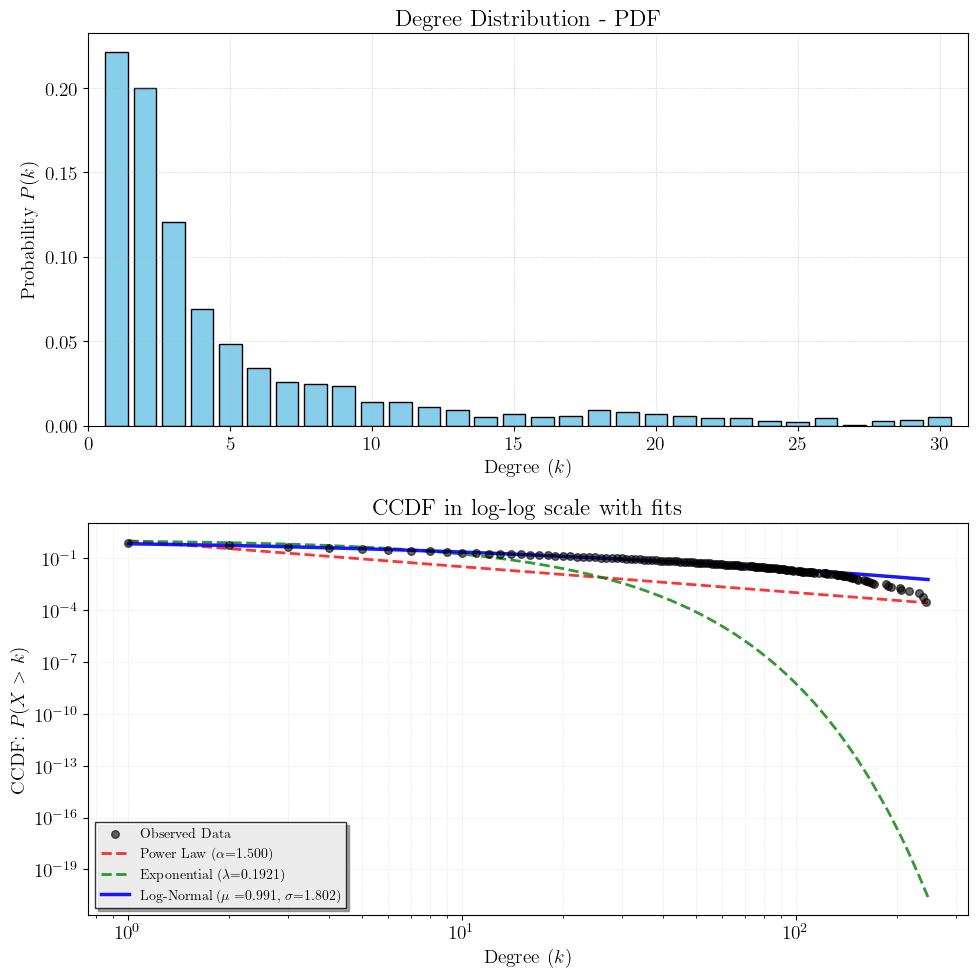

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# SUBPLOT 1: PDF (only first 30 degrees for clarity)
max_degree_pdf = 30
mask_pdf = unique_degrees <= max_degree_pdf
ax1 = axes[0]
ax1.bar(unique_degrees[mask_pdf], pdf[mask_pdf], color='skyblue', edgecolor='black')
ax1.set_xlabel('Degree $(k)$')
ax1.set_ylabel('Probability $P(k)$')
ax1.set_title('Degree Distribution - PDF')
ax1.set_xlim(0, max_degree_pdf + 1)

# SUBPLOT 2: CCDF in log-log scale with fits
ax2 = axes[1]

# Data
ax2.scatter(degrees_fit, ccdf_data, s=30, alpha=0.6, color='black', 
            label='Observed Data', zorder=5)

# Power Law (if valid)
if popt_pl is not None:
    ax2.plot(degrees_fit, power_law_ccdf(degrees_fit, *popt_pl), 
             'r--', linewidth=2, alpha=0.8, label=f'Power Law ($\\alpha$={alpha_fit:.3f})')

# Exponential (if valid)
if popt_exp is not None:
    ax2.plot(degrees_fit, exponential_ccdf(degrees_fit, *popt_exp), 
             'g--', linewidth=2, alpha=0.8, label=f'Exponential ($\\lambda$={lambda_fit:.4f})')

# Log-Normal (if valid)
if popt_ln is not None:
    ax2.plot(degrees_fit, lognormal_ccdf(degrees_fit, *popt_ln), 
             'b-', linewidth=2.5, alpha=0.9, label=f'Log-Normal ($\\mu=${mu_fit:.3f}, $\\sigma$={sigma_fit:.3f})')

ax2.set_xlabel('Degree $(k)$')
ax2.set_ylabel('CCDF: $P(X > k)$')
ax2.set_title('CCDF in log-log scale with fits')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('../results/figures/degree_distribution_analysis.pdf', bbox_inches='tight')
print("Saved plot as 'degree_distribution_analysis.pdf'")


---
## Centrality structure
Rank the top 25 nodes by each of the following centrality measures:
- Degree
- Betweenness
- Closeness
- Eigenvector
- Katz
- PageRank
- Subgraph

In [26]:
# Calculate centrality measures
degree_centrality = nx.degree_centrality(G_giant)
closeness_centrality = nx.closeness_centrality(G_giant)
betweenness_centrality = nx.betweenness_centrality(G_giant)
eigenvector_centrality = nx.eigenvector_centrality(G_giant, max_iter=1000, tol=1e-06)
katz_centrality = nx.katz_centrality_numpy(G_giant)
pagerank_centrality = nx.pagerank(G_giant)
subgraph_centrality = nx.subgraph_centrality(G_giant)

# Create a DataFrame with the results
df = pd.DataFrame({
    'degree centrality': degree_centrality,
    'closeness': closeness_centrality,
    'betweenness': betweenness_centrality,
    'eigenvector': eigenvector_centrality,
    'katz': katz_centrality,
    'pagerank': pagerank_centrality,
    'subgraph': subgraph_centrality
})

# Ranking of the top 25 for each measure
top_degree = df['degree centrality'].sort_values(ascending=False).head(25).index
top_closeness = df['closeness'].sort_values(ascending=False).head(25).index
top_betweenness = df['betweenness'].sort_values(ascending=False).head(25).index
top_eigenvector = df['eigenvector'].sort_values(ascending=False).head(25).index
top_katz = df['katz'].sort_values(ascending=False).head(25).index
top_pagerank = df['pagerank'].sort_values(ascending=False).head(25).index
top_subgraph = df['subgraph'].sort_values(ascending=False).head(25).index

# Concatenate results into a single DataFrame for comparison
ranking_df = pd.DataFrame({
    'degree centrality': top_degree,
    'closeness': top_closeness,
    'betweenness': top_betweenness,
    'eigenvector': top_eigenvector,
    'katz': top_katz,
    'pagerank': top_pagerank,
    'subgraph': top_subgraph
})

ranking_df

,degree centrality,closeness,betweenness,eigenvector,katz,pagerank,subgraph
0,580.0,340.0,1382.0,580.0,2899.0,3682.0,580.0
1,340.0,1382.0,3484.0,340.0,302.0,3830.0,340.0
2,1382.0,507.0,3774.0,1382.0,2883.0,1701.0,1382.0
3,1701.0,580.0,2188.0,346.0,1804.0,3670.0,346.0
4,3682.0,2188.0,340.0,1555.0,3043.0,3751.0,1555.0
5,3830.0,3484.0,580.0,507.0,3830.0,1382.0,507.0
6,3364.0,3797.0,3364.0,1701.0,492.0,4029.0,1701.0
7,346.0,193.0,3830.0,1218.0,3797.0,580.0,1218.0
8,3670.0,1701.0,193.0,1678.0,3382.0,340.0,1678.0
9,4029.0,346.0,1701.0,1229.0,3239.0,3364.0,1229.0


In [27]:
# Overlap analysis
# Degree vs others
overlap_degree_closeness = len(set(top_degree).intersection(set(top_closeness)))
overlap_degree_betweenness = len(set(top_degree).intersection(set(top_betweenness)))
overlap_degree_eigenvector = len(set(top_degree).intersection(set(top_eigenvector)))
overlap_degree_katz = len(set(top_degree).intersection(set(top_katz)))
overlap_degree_pagerank = len(set(top_degree).intersection(set(top_pagerank)))
overlap_degree_subgraph = len(set(top_degree).intersection(set(top_subgraph)))

# Closness vs others
overlap_closeness_betweenness = len(set(top_closeness).intersection(set(top_betweenness)))
overlap_closeness_eigenvector = len(set(top_closeness).intersection(set(top_eigenvector)))
overlap_closeness_katz = len(set(top_closeness).intersection(set(top_katz)))
overlap_closeness_pagerank = len(set(top_closeness).intersection(set(top_pagerank)))
overlap_closeness_subgraph = len(set(top_closeness).intersection(set(top_subgraph)))

# Betweenness vs others
overlap_betweenness_eigenvector = len(set(top_betweenness).intersection(set(top_eigenvector)))
overlap_betweenness_katz = len(set(top_betweenness).intersection(set(top_katz)))
overlap_betweenness_pagerank = len(set(top_betweenness).intersection(set(top_pagerank)))
overlap_betweenness_subgraph = len(set(top_betweenness).intersection(set(top_subgraph)))

# Eigenvector vs others
overlap_eigenvector_katz = len(set(top_eigenvector).intersection(set(top_katz)))
overlap_eigenvector_pagerank = len(set(top_eigenvector).intersection(set(top_pagerank)))
overlap_eigenvector_subgraph = len(set(top_eigenvector).intersection(set(top_subgraph)))

# Katz vs others
overlap_katz_pagerank = len(set(top_katz).intersection(set(top_pagerank)))
overlap_katz_subgraph = len(set(top_katz).intersection(set(top_subgraph)))

# Pagerank vs subgraph
overlap_pagerank_subgraph = len(set(top_pagerank).intersection(set(top_subgraph)))

print(f"\nMain overlaps among top 25:")
print(f"Degree-Closeness: {overlap_degree_closeness} nodes")
print(f"Degree-Betweenness: {overlap_degree_betweenness} nodes")
print(f"Degree-Eigenvector: {overlap_degree_eigenvector} nodes")
print(f"Degree-Katz: {overlap_degree_katz} nodes")
print(f"Degree-Pagerank: {overlap_degree_pagerank} nodes")
print(f"Degree-Subgraph: {overlap_degree_subgraph} nodes")
print(f"Closeness-Betweenness: {overlap_closeness_betweenness} nodes")
print(f"Closeness-Eigenvector: {overlap_closeness_eigenvector} nodes")
print(f"Closeness-Katz: {overlap_closeness_katz} nodes")
print(f"Closeness-Pagerank: {overlap_closeness_pagerank} nodes")
print(f"Closeness-Subgraph: {overlap_closeness_subgraph} nodes")
print(f"Betweenness-Eigenvector: {overlap_betweenness_eigenvector} nodes")
print(f"Betweenness-Katz: {overlap_betweenness_katz} nodes")
print(f"Betweenness-Pagerank: {overlap_betweenness_pagerank} nodes")
print(f"Betweenness-Subgraph: {overlap_betweenness_subgraph} nodes")
print(f"Eigenvector-Katz: {overlap_eigenvector_katz} nodes")
print(f"Eigenvector-Pagerank: {overlap_eigenvector_pagerank} nodes")
print(f"Eigenvector-Subgraph: {overlap_eigenvector_subgraph} nodes")

# Save centrality measures to HDF5
df.to_hdf('../results/tables/centrality_measures_airport_network.h5', key='centrality', mode='w', index=True)


Main overlaps among top 25:
Degree-Closeness: 17 nodes
Degree-Betweenness: 14 nodes
Degree-Eigenvector: 14 nodes
Degree-Katz: 5 nodes
Degree-Pagerank: 17 nodes
Degree-Subgraph: 14 nodes
Closeness-Betweenness: 16 nodes
Closeness-Eigenvector: 11 nodes
Closeness-Katz: 4 nodes
Closeness-Pagerank: 15 nodes
Closeness-Subgraph: 11 nodes
Betweenness-Eigenvector: 7 nodes
Betweenness-Katz: 3 nodes
Betweenness-Pagerank: 17 nodes
Betweenness-Subgraph: 7 nodes
Eigenvector-Katz: 2 nodes
Eigenvector-Pagerank: 8 nodes
Eigenvector-Subgraph: 25 nodes


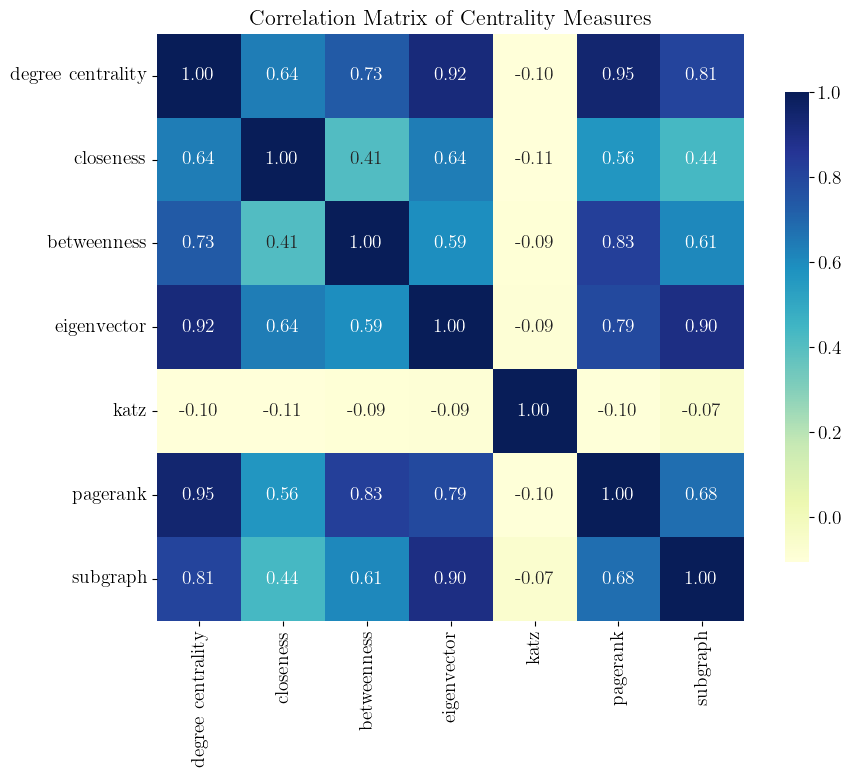

In [28]:
# Plot correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='YlGnBu', square=True, cbar_kws={"shrink": .8})
plt.grid(False)
plt.title('Correlation Matrix of Centrality Measures', fontsize=16)
plt.tight_layout()
plt.savefig('../results/figures/centrality_correlation_heatmap.pdf', bbox_inches='tight')
plt.show()

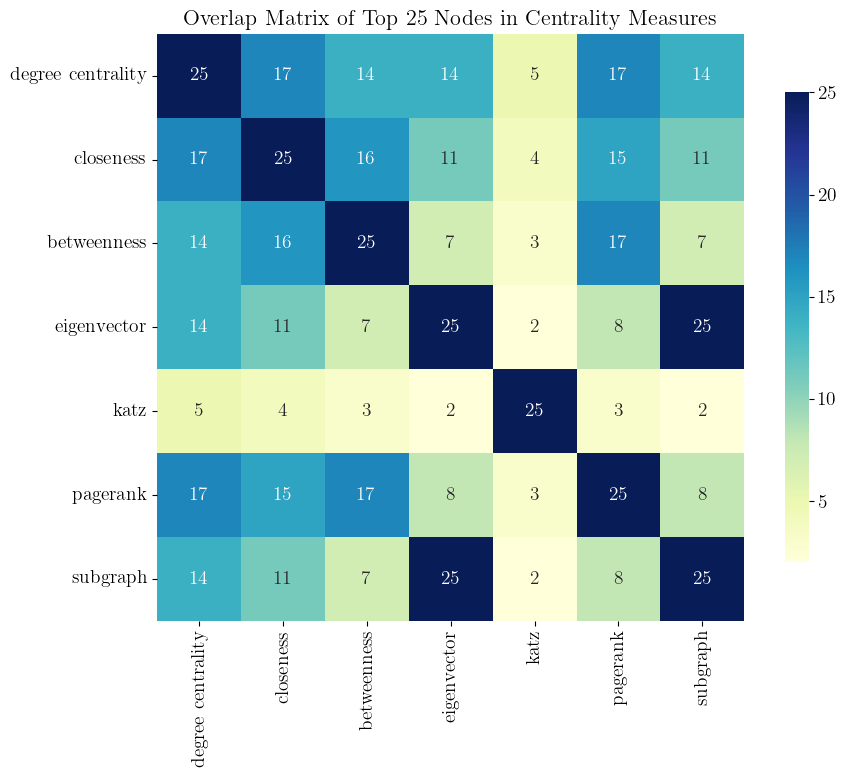

In [29]:
# Plot overlap heatmap
overlap_matrix = pd.DataFrame(index=df.columns, columns=df.columns, data=0)
for measure1 in df.columns:
    for measure2 in df.columns:
        top1 = set(df[measure1].sort_values(ascending=False).head(25).index)
        top2 = set(df[measure2].sort_values(ascending=False).head(25).index)
        overlap_matrix.loc[measure1, measure2] = len(top1.intersection(top2))
plt.figure(figsize=(10, 8))
sns.heatmap(overlap_matrix.astype(int), annot=True, fmt="d", cmap='YlGnBu', square=True, cbar_kws={"shrink": .8})
plt.grid(False)
plt.title('Overlap Matrix of Top 25 Nodes in Centrality Measures', fontsize=16)
plt.tight_layout()
plt.savefig('../results/figures/centrality_overlap_heatmap.pdf', bbox_inches='tight')
plt.show()


---
## Null models
- Erdos-Renyi
- Barabasi-Albert

### Erdos-Renyi


DEGREE STATISTICS (Erdős-Rényi Graph 1):
  Minimum degree:        2
  Maximum degree:        25
  Average degree:        11.805
  Median degree:         12.0
  Standard deviation:    3.426
  Total nodes:           3188

Statistics for the 10 ER networks:
  Average nodes: 3188
  Average edges: 18809
  Average density: 0.003703
  Average clustering coefficient: 0.003665
  Average shortest path length (if connected): 3.195223

Comparison with G_giant:
  G_giant nodes: 3188
  G_giant edges: 18833
  G_giant density: 0.003707
  G_giant average clustering coefficient: 0.492830

Statistics for the 10 ER networks:
  Average nodes: 3188
  Average edges: 18809
  Average density: 0.003703
  Average clustering coefficient: 0.003665
  Average shortest path length (if connected): 3.195223

Comparison with G_giant:
  G_giant nodes: 3188
  G_giant edges: 18833
  G_giant density: 0.003707
  G_giant average clustering coefficient: 0.492830
  G_giant average shortest path length (if connected): 3.9585303

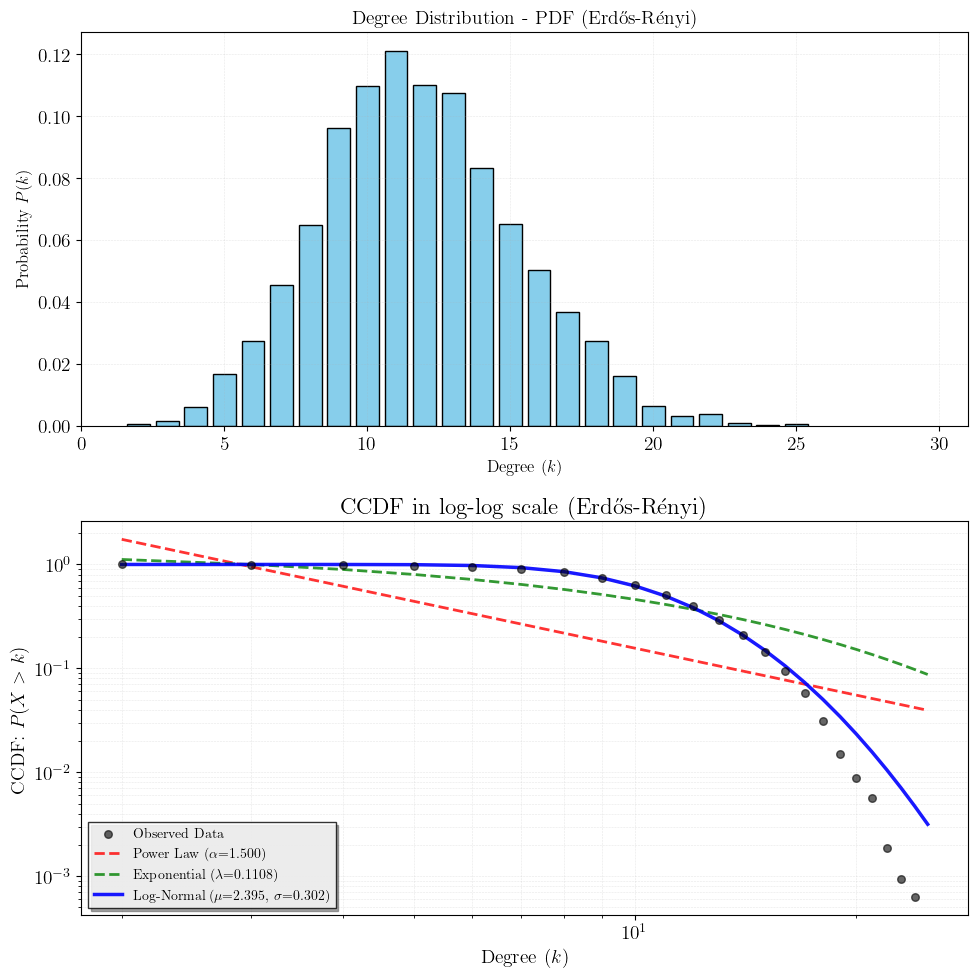

In [46]:
# Calculate ER parameters
num_nodes = G_giant.number_of_nodes()
num_edges = G_giant.number_of_edges()
p = 2 * num_edges / (num_nodes * (num_nodes - 1))

# Generate 10 ER graphs
er_graphs = []
for i in range(10):
    G_er = nx.gnp_random_graph(num_nodes, p, seed=i)
    er_graphs.append(G_er)

# Use first ER graph for PDF/CCDF analysis
G_er_sample = er_graphs[0]

# ============================================================================
# CALCULATE DEGREES FOR G_ER
# ============================================================================

degrees = [G_er_sample.degree(n) for n in G_er_sample.nodes()]
degrees_array = np.array(degrees)

print(f"\nDEGREE STATISTICS (Erdős-Rényi Graph 1):")
print(f"  Minimum degree:        {np.min(degrees)}")
print(f"  Maximum degree:        {np.max(degrees)}")
print(f"  Average degree:        {np.mean(degrees):.3f}")
print(f"  Median degree:         {np.median(degrees):.1f}")
print(f"  Standard deviation:    {np.std(degrees):.3f}")
print(f"  Total nodes:           {len(degrees)}")

# ============================================================================
# AVERAGES STATISTICS FOR G_ER
# ============================================================================

# Average statistics of the 10 ER graphs
avg_nodes = sum(g.number_of_nodes() for g in er_graphs) / 10
avg_edges = sum(g.number_of_edges() for g in er_graphs) / 10
avg_density = sum(nx.density(g) for g in er_graphs) / 10
avg_clustering = sum(nx.average_clustering(g) for g in er_graphs) / 10
avg_shortest_path_length = sum(nx.average_shortest_path_length(g) if nx.is_connected(g) else 0 for g in er_graphs) / 10
avg_effective_diameter = sum(np.percentile([d for source in g.nodes() for target, d in nx.single_source_shortest_path_length(g, source).items() if source != target], 90) for g in er_graphs) / 10

print(f"\n{'='*50}")
print(f"Statistics for the 10 ER networks:")
print(f"  Average nodes: {avg_nodes:.0f}")
print(f"  Average edges: {avg_edges:.0f}")
print(f"  Average density: {avg_density:.6f}")
print(f"  Average clustering coefficient: {avg_clustering:.6f}")
print(f"  Average shortest path length (if connected): {avg_shortest_path_length:.6f}")

print(f"\nComparison with G_giant:")
print(f"  G_giant nodes: {num_nodes}")
print(f"  G_giant edges: {num_edges}")
print(f"  G_giant density: {nx.density(G_giant):.6f}")
print(f"  G_giant average clustering coefficient: {nx.average_clustering(G_giant):.6f}")
print(f"  G_giant average shortest path length (if connected): {nx.average_shortest_path_length(G_giant) if nx.is_connected(G_giant) else 'N/A (not connected)'}")

# ============================================================================
# PDF AND CCDF FOR G_ER
# ============================================================================

# PDF
unique_degrees, counts = np.unique(degrees, return_counts=True)
pdf = counts / len(degrees)

# CCDF
ccdf = []
for k in unique_degrees:
    count_greater = np.sum(degrees_array > k)
    ccdf.append(count_greater / len(degrees_array))
ccdf = np.array(ccdf)

print(f"\nUnique degrees: {len(unique_degrees)}")
print(f"\nFirst 10 degrees and their frequencies:")
print(f"{'Degree':<10} {'Frequency':<15} {'Percentage':<15}")
print("-" * 40)
for i in range(min(10, len(unique_degrees))):
    print(f"{unique_degrees[i]:<10} {counts[i]:<15} {pdf[i]*100:>6.2f}%")

# ============================================================================
# DISTRIBUTION FUNCTIONS
# ============================================================================

def power_law_ccdf(k, alpha, k_min):
    """Power law: P(X > k) = (k/k_min)^(-alpha)"""
    return (k / k_min) ** (-alpha)

def exponential_ccdf(k, lambda_param, k_min):
    """Exponential: P(X > k) = exp(-lambda*(k-k_min))"""
    return np.exp(-lambda_param * (k - k_min))

def lognormal_ccdf(k, mu, sigma, k_min):
    """Log-normal: P(X > k) for log-normal distribution"""
    return 1 - stats.lognorm.cdf(k, sigma, scale=np.exp(mu))

# Prepare data for fitting
k_min = np.min(unique_degrees)
ccdf_data = ccdf[unique_degrees >= k_min]
degrees_fit = unique_degrees[unique_degrees >= k_min]

# ============================================================================
# FIT 1: POWER LAW
# ============================================================================

print(f"\n{'='*80}")
print("FITTING DISTRIBUTIONS (ER Network)")
print(f"{'='*80}\n")

print("1. POWER LAW")
print("-" * 50)

try:
    popt_pl, _ = curve_fit(
        power_law_ccdf, 
        degrees_fit, 
        ccdf_data,
        p0=[2.5, k_min],
        maxfev=10000,
        bounds=([1.5, k_min], [5, k_min+1])
    )
    alpha_fit, k_min_fit = popt_pl
    y_pred_pl = power_law_ccdf(degrees_fit, *popt_pl)
    ss_res_pl = np.sum((ccdf_data - y_pred_pl) ** 2)
    ss_tot = np.sum((ccdf_data - np.mean(ccdf_data)) ** 2)
    r2_pl = 1 - (ss_res_pl / ss_tot) if ss_tot != 0 else 0
    ks_stat_pl = np.max(np.abs(ccdf_data - y_pred_pl))
    
    print(f"  Parameters found:")
    print(f"    - α (exponent): {alpha_fit:.4f}")
    print(f"    - k_min: {k_min_fit:.1f}")
    print(f"  Goodness of fit:")
    print(f"    - R²: {r2_pl:.6f}")
    print(f"    - KS statistic: {ks_stat_pl:.6f}")
    
except Exception as e:
    print(f"  Error: {e}")
    popt_pl = None
    r2_pl = -1
    ks_stat_pl = 999

# ============================================================================
# FIT 2: EXPONENTIAL
# ============================================================================

print("\n2. EXPONENTIAL")
print("-" * 50)

try:
    popt_exp, _ = curve_fit(
        exponential_ccdf,
        degrees_fit,
        ccdf_data,
        p0=[0.1, k_min],
        maxfev=10000,
        bounds=([0.01, k_min], [1, k_min+1])
    )
    lambda_fit, k_min_exp = popt_exp
    y_pred_exp = exponential_ccdf(degrees_fit, *popt_exp)
    ss_res_exp = np.sum((ccdf_data - y_pred_exp) ** 2)
    r2_exp = 1 - (ss_res_exp / ss_tot) if ss_tot != 0 else 0
    ks_stat_exp = np.max(np.abs(ccdf_data - y_pred_exp))
    
    print(f"  Parameters found:")
    print(f"    - λ (lambda): {lambda_fit:.6f}")
    print(f"    - k_min: {k_min_exp:.1f}")
    print(f"  Goodness of fit:")
    print(f"    - R²: {r2_exp:.6f}")
    print(f"    - KS statistic: {ks_stat_exp:.6f}")
    
except Exception as e:
    print(f"  Error: {e}")
    popt_exp = None
    r2_exp = -1
    ks_stat_exp = 999

# ============================================================================
# FIT 3: LOG-NORMAL
# ============================================================================

print("\n3. LOG-NORMAL")
print("-" * 50)

try:
    popt_ln, _ = curve_fit(
        lognormal_ccdf,
        degrees_fit,
        ccdf_data,
        p0=[2, 1, k_min],
        maxfev=10000,
        bounds=([0, 0.1, k_min], [5, 3, k_min+1])
    )
    mu_fit, sigma_fit, k_min_ln = popt_ln
    y_pred_ln = lognormal_ccdf(degrees_fit, *popt_ln)
    ss_res_ln = np.sum((ccdf_data - y_pred_ln) ** 2)
    r2_ln = 1 - (ss_res_ln / ss_tot) if ss_tot != 0 else 0
    ks_stat_ln = np.max(np.abs(ccdf_data - y_pred_ln))
    
    print(f"  Parameters found:")
    print(f"    - μ (mean): {mu_fit:.4f}")
    print(f"    - σ (standard deviation): {sigma_fit:.4f}")
    print(f"    - k_min: {k_min_ln:.1f}")
    print(f"  Goodness of fit:")
    print(f"    - R²: {r2_ln:.6f}")
    print(f"    - KS statistic: {ks_stat_ln:.6f}")
    
except Exception as e:
    print(f"  Error: {e}")
    popt_ln = None
    r2_ln = -1
    ks_stat_ln = 999

# ============================================================================
# COMPARISON
# ============================================================================

print(f"\n{'='*80}")
print("COMPARISON OF GOODNESS OF FIT")
print(f"{'='*80}\n")

results = pd.DataFrame({
    'Distribution': ['Power Law', 'Exponential', 'Log-Normal'],
    'R²': [r2_pl, r2_exp, r2_ln],
    'KS statistic': [ks_stat_pl, ks_stat_exp, ks_stat_ln]
})

print(results.to_string(index=False))

best_idx = results['R²'].idxmax()
best_fit = results.loc[best_idx, 'Distribution']
best_r2 = results.loc[best_idx, 'R²']

print(f"\nFINAL RESULT: {best_fit} (R² = {best_r2:.6f})")

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# SUBPLOT 1: PDF
max_degree_pdf = 30
mask_pdf = unique_degrees <= max_degree_pdf
ax1 = axes[0]
ax1.bar(unique_degrees[mask_pdf], pdf[mask_pdf], color='skyblue', edgecolor='black')
ax1.set_xlabel('Degree $(k)$', fontsize=12, fontweight='bold')
ax1.set_ylabel('Probability $P(k)$', fontsize=12, fontweight='bold')
ax1.set_title('Degree Distribution - PDF (Erdős-Rényi)', fontsize=14, fontweight='bold')
ax1.set_xlim(0, max_degree_pdf + 1)
ax1.grid(True, alpha=0.3)

# SUBPLOT 2: CCDF
ax2 = axes[1]
ax2.scatter(degrees_fit, ccdf_data, s=30, alpha=0.6, color='black', 
            label='Observed Data', zorder=5)

if popt_pl is not None:
    ax2.plot(degrees_fit, power_law_ccdf(degrees_fit, *popt_pl), 
             'r--', linewidth=2, alpha=0.8, label=f'Power Law ($\\alpha$={alpha_fit:.3f})')

if popt_exp is not None:
    ax2.plot(degrees_fit, exponential_ccdf(degrees_fit, *popt_exp), 
             'g--', linewidth=2, alpha=0.8, label=f'Exponential ($\\lambda$={lambda_fit:.4f})')

if popt_ln is not None:
    ax2.plot(degrees_fit, lognormal_ccdf(degrees_fit, *popt_ln), 
             'b-', linewidth=2.5, alpha=0.9, label=f'Log-Normal ($\\mu$={mu_fit:.3f}, $\\sigma$={sigma_fit:.3f})')

ax2.set_xlabel('Degree $(k)$')
ax2.set_ylabel('CCDF: $P(X > k)$')
ax2.set_title('CCDF in log-log scale (Erdős-Rényi)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('../results/figures/degree_distribution_analysis_er.pdf', bbox_inches='tight')
plt.show()


DEGREE STATISTICS (Average of 10 Erdős-Rényi Graphs):
  Minimum degree:        0
  Maximum degree:        27
  Average degree:        11.800
  Median degree:         12.0
  Standard deviation:    3.424

FITTING DISTRIBUTIONS (Average ER Network)

1. POWER LAW
--------------------------------------------------
  Parameters found:
    - α (exponent): 2.5000
    - k_min: 0.0
  Goodness of fit:
    - R²: -0.810041
    - KS statistic: 0.999906

2. EXPONENTIAL
--------------------------------------------------
  Parameters found:
    - λ (lambda): 0.089583
    - k_min: 1.0
  Goodness of fit:
    - R²: 0.822608
    - KS statistic: 0.317923

3. LOG-NORMAL
--------------------------------------------------
  Parameters found:
    - μ (mean): 2.3947
    - σ (standard deviation): 0.3020
    - k_min: 0.0
  Goodness of fit:
    - R²: 0.998970
    - KS statistic: 0.029238

COMPARISON OF GOODNESS OF FIT

Distribution        R²  KS statistic
   Power Law -0.810041      0.999906
 Exponential  0.822608

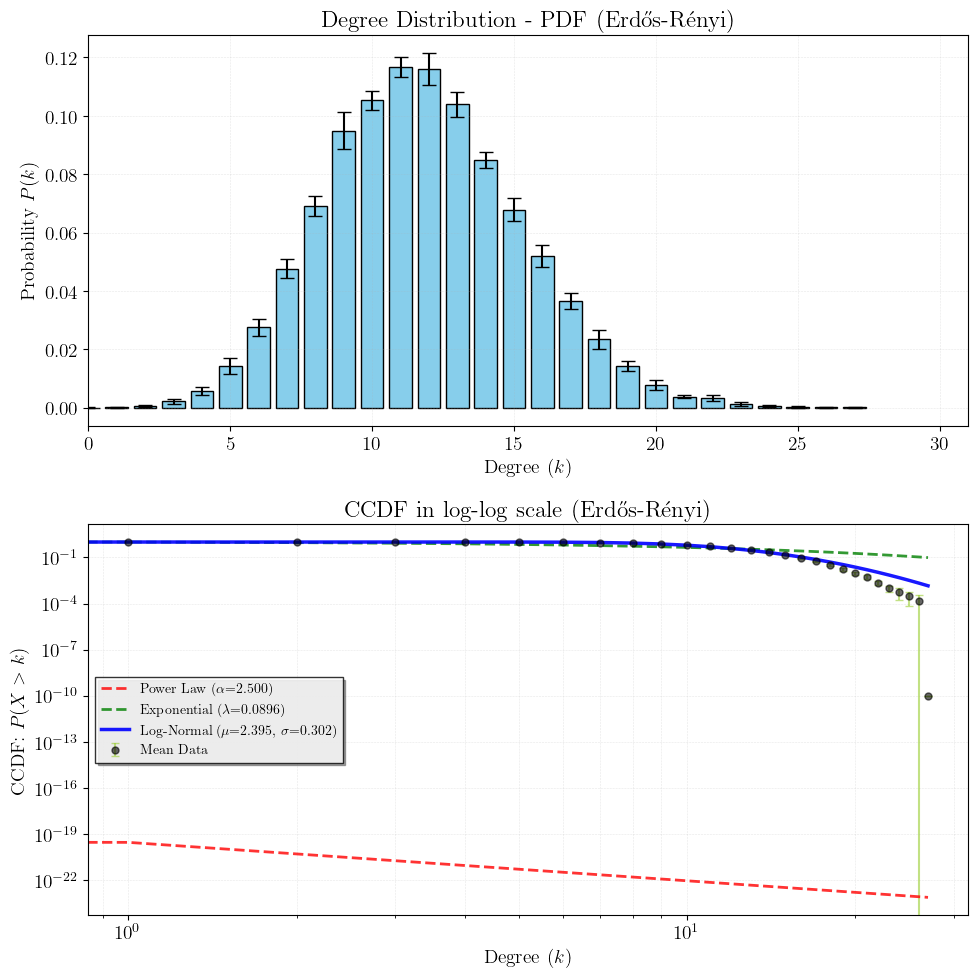

In [47]:
# ============================================================================
# CALCULATE DEGREES FOR ALL 10 ER GRAPHS
# ============================================================================

all_degrees = []
for i, G_er in enumerate(er_graphs):
    degrees = [G_er.degree(n) for n in G_er.nodes()]
    all_degrees.append(degrees)

all_degrees = np.array(all_degrees)

# Calculate mean and std for each degree value across all 10 networks
unique_degrees_all = np.unique(np.concatenate(all_degrees))

# Calculate PDF and CCDF statistics across all networks
pdf_mean = []
pdf_std = []
ccdf_mean = []
ccdf_std = []

for k in unique_degrees_all:
    # PDF calculation for all networks
    pdf_values = []
    ccdf_values = []
    
    for degrees in all_degrees:
        degrees_array = np.array(degrees)
        
        # PDF
        count = np.sum(degrees_array == k)
        pdf_val = count / len(degrees_array)
        pdf_values.append(pdf_val)
        
        # CCDF
        count_greater = np.sum(degrees_array > k)
        ccdf_val = count_greater / len(degrees_array)
        ccdf_values.append(ccdf_val)
    
    pdf_mean.append(np.mean(pdf_values))
    pdf_std.append(np.std(pdf_values))
    ccdf_mean.append(np.mean(ccdf_values))
    ccdf_std.append(np.std(ccdf_values))

pdf_mean = np.array(pdf_mean)
pdf_std = np.array(pdf_std)
ccdf_mean = np.array(ccdf_mean)
ccdf_std = np.array(ccdf_std)

print(f"\nDEGREE STATISTICS (Average of 10 Erdős-Rényi Graphs):")
print(f"  Minimum degree:        {np.min(unique_degrees_all)}")
print(f"  Maximum degree:        {np.max(unique_degrees_all)}")
print(f"  Average degree:        {np.mean(np.concatenate(all_degrees)):.3f}")
print(f"  Median degree:         {np.median(np.concatenate(all_degrees)):.1f}")
print(f"  Standard deviation:    {np.std(np.concatenate(all_degrees)):.3f}")

# Filter data to avoid divide by zero and invalid operations
k_min = np.min(unique_degrees_all)
ccdf_data = ccdf_mean[unique_degrees_all >= k_min]
degrees_fit = unique_degrees_all[unique_degrees_all >= k_min]

# Add small epsilon to avoid log(0) and divide by zero
epsilon = 1e-10
ccdf_data = np.clip(ccdf_data, epsilon, 1.0)

# Calculate upper and lower bounds for CCDF error bars
ccdf_upper = ccdf_mean + ccdf_std
ccdf_lower = np.maximum(ccdf_mean - ccdf_std, epsilon)  # Ensure no negative values

# ============================================================================
# DISTRIBUTION FUNCTIONS
# ============================================================================

def power_law_ccdf(k, alpha, k_min):
    """Power law: P(X > k) = (k/k_min)^(-alpha)"""
    k_safe = np.maximum(k, k_min + epsilon)
    return np.power(k_safe / k_min, -alpha)

def exponential_ccdf(k, lambda_param, k_min):
    """Exponential: P(X > k) = exp(-lambda*(k-k_min))"""
    return np.exp(-lambda_param * np.maximum(k - k_min, 0))

def lognormal_ccdf(k, mu, sigma, k_min):
    """Log-normal: P(X > k) for log-normal distribution"""
    k_safe = np.maximum(k, k_min + epsilon)
    return 1 - stats.lognorm.cdf(k_safe, sigma, scale=np.exp(mu))


# ============================================================================
# FIT 1: POWER LAW
# ============================================================================

print(f"\n{'='*80}")
print("FITTING DISTRIBUTIONS (Average ER Network)")
print(f"{'='*80}\n")

print("1. POWER LAW")
print("-" * 50)

try:
    popt_pl, _ = curve_fit(
        power_law_ccdf, 
        degrees_fit, 
        ccdf_data,
        p0=[2.5, k_min],
        maxfev=10000,
        bounds=([1.5, k_min], [5, k_min+1])
    )
    alpha_fit, k_min_fit = popt_pl
    y_pred_pl = power_law_ccdf(degrees_fit, *popt_pl)
    ss_res_pl = np.sum((ccdf_data - y_pred_pl) ** 2)
    ss_tot = np.sum((ccdf_data - np.mean(ccdf_data)) ** 2)
    r2_pl = 1 - (ss_res_pl / ss_tot) if ss_tot != 0 else 0
    ks_stat_pl = np.max(np.abs(ccdf_data - y_pred_pl))
    
    print(f"  Parameters found:")
    print(f"    - α (exponent): {alpha_fit:.4f}")
    print(f"    - k_min: {k_min_fit:.1f}")
    print(f"  Goodness of fit:")
    print(f"    - R²: {r2_pl:.6f}")
    print(f"    - KS statistic: {ks_stat_pl:.6f}")
    
except Exception as e:
    print(f"  Error: {e}")
    popt_pl = None
    r2_pl = -1
    ks_stat_pl = 999

# ============================================================================
# FIT 2: EXPONENTIAL
# ============================================================================

print("\n2. EXPONENTIAL")
print("-" * 50)

try:
    popt_exp, _ = curve_fit(
        exponential_ccdf,
        degrees_fit,
        ccdf_data,
        p0=[0.1, k_min],
        maxfev=10000,
        bounds=([0.01, k_min], [1, k_min+1])
    )
    lambda_fit, k_min_exp = popt_exp
    y_pred_exp = exponential_ccdf(degrees_fit, *popt_exp)
    ss_res_exp = np.sum((ccdf_data - y_pred_exp) ** 2)
    r2_exp = 1 - (ss_res_exp / ss_tot) if ss_tot != 0 else 0
    ks_stat_exp = np.max(np.abs(ccdf_data - y_pred_exp))
    
    print(f"  Parameters found:")
    print(f"    - λ (lambda): {lambda_fit:.6f}")
    print(f"    - k_min: {k_min_exp:.1f}")
    print(f"  Goodness of fit:")
    print(f"    - R²: {r2_exp:.6f}")
    print(f"    - KS statistic: {ks_stat_exp:.6f}")
    
except Exception as e:
    print(f"  Error: {e}")
    popt_exp = None
    r2_exp = -1
    ks_stat_exp = 999

# ============================================================================
# FIT 3: LOG-NORMAL
# ============================================================================

print("\n3. LOG-NORMAL")
print("-" * 50)

try:
    popt_ln, _ = curve_fit(
        lognormal_ccdf,
        degrees_fit,
        ccdf_data,
        p0=[2, 1, k_min],
        maxfev=10000,
        bounds=([0, 0.1, k_min], [5, 3, k_min+1])
    )
    mu_fit, sigma_fit, k_min_ln = popt_ln
    y_pred_ln = lognormal_ccdf(degrees_fit, *popt_ln)
    ss_res_ln = np.sum((ccdf_data - y_pred_ln) ** 2)
    r2_ln = 1 - (ss_res_ln / ss_tot) if ss_tot != 0 else 0
    ks_stat_ln = np.max(np.abs(ccdf_data - y_pred_ln))
    
    print(f"  Parameters found:")
    print(f"    - μ (mean): {mu_fit:.4f}")
    print(f"    - σ (standard deviation): {sigma_fit:.4f}")
    print(f"    - k_min: {k_min_ln:.1f}")
    print(f"  Goodness of fit:")
    print(f"    - R²: {r2_ln:.6f}")
    print(f"    - KS statistic: {ks_stat_ln:.6f}")
    
except Exception as e:
    print(f"  Error: {e}")
    popt_ln = None
    r2_ln = -1
    ks_stat_ln = 999

# ============================================================================
# COMPARISON
# ============================================================================

print(f"\n{'='*80}")
print("COMPARISON OF GOODNESS OF FIT")
print(f"{'='*80}\n")

results = pd.DataFrame({
    'Distribution': ['Power Law', 'Exponential', 'Log-Normal'],
    'R²': [r2_pl, r2_exp, r2_ln],
    'KS statistic': [ks_stat_pl, ks_stat_exp, ks_stat_ln]
})

print(results.to_string(index=False))

best_idx = results['R²'].idxmax()
best_fit = results.loc[best_idx, 'Distribution']
best_r2 = results.loc[best_idx, 'R²']

print(f"\nFINAL RESULT: {best_fit} (R² = {best_r2:.6f})")

# ============================================================================
# VISUALIZATION WITH ERROR BARS AND FILL_BETWEEN
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# SUBPLOT 1: PDF WITH ERROR BARS
max_degree_pdf = 30
mask_pdf = unique_degrees_all <= max_degree_pdf
ax1 = axes[0]
ax1.bar(unique_degrees_all[mask_pdf], pdf_mean[mask_pdf], 
        yerr=pdf_std[mask_pdf], color='skyblue', edgecolor='black', capsize=5)
ax1.set_xlabel('Degree $(k)$')
ax1.set_ylabel('Probability $P(k)$')
ax1.set_title('Degree Distribution - PDF (Erdős-Rényi)')
ax1.set_xlim(0, max_degree_pdf + 1)
ax1.grid(True, alpha=0.3)

# SUBPLOT 2: CCDF WITH ERROR BARS
ax2 = axes[1]

# Get the indices that match degrees_fit
mask_fit = unique_degrees_all >= k_min

# Extract error bands for only the fitted degrees
ccdf_upper_fit = ccdf_upper[mask_fit]
ccdf_lower_fit = ccdf_lower[mask_fit]

# Calculate error bars (symmetric)
ccdf_yerr = ccdf_std[mask_fit]

# Mean data with error bars
# Mean data with error bars
ax2.errorbar(degrees_fit, ccdf_data, yerr=ccdf_yerr, fmt='o', 
             markersize=5, alpha=0.6, color='black',  # Color de los puntos
             ecolor='yellowgreen',                    # Color de las barras de error
             label='Mean Data', capsize=3, capthick=1)

# Fits
if popt_pl is not None:
    ax2.plot(degrees_fit, power_law_ccdf(degrees_fit, *popt_pl), 
             'r--', linewidth=2, alpha=0.8, label=f'Power Law ($\\alpha$={alpha_fit:.3f})')

if popt_exp is not None:
    ax2.plot(degrees_fit, exponential_ccdf(degrees_fit, *popt_exp), 
             'g--', linewidth=2, alpha=0.8, label=f'Exponential ($\\lambda$={lambda_fit:.4f})')

if popt_ln is not None:
    ax2.plot(degrees_fit, lognormal_ccdf(degrees_fit, *popt_ln), 
             'b-', linewidth=2.5, alpha=0.9, label=f'Log-Normal ($\\mu$={mu_fit:.3f}, $\\sigma$={sigma_fit:.3f})')

ax2.set_xlabel('Degree $(k)$')
ax2.set_ylabel('CCDF: $P(X > k)$')
ax2.set_title('CCDF in log-log scale (Erdős-Rényi)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('../results/figures/degree_distribution_analysis_er_with_errors.pdf', bbox_inches='tight')
plt.show()


### Barabasi-Albert

Barabási-Albert Model Parameters:
  Number of nodes: 3188
  Number of edges: 18833
  Average degree: 11.815
  m (edges per new node): 5

DEGREE STATISTICS (Barabási-Albert Graph 1):
  Minimum degree:        5
  Maximum degree:        195
  Average degree:        9.984
  Median degree:         7.0
  Standard deviation:    11.961
  Total nodes:           3188

Statistics for the 10 BA networks:
  Average nodes: 3188
  Average edges: 15915
  Average density: 0.003133
  Average clustering coefficient: 0.017073
  Average shortest path length (if connected): 3.338872
  Average effective diameter (90th percentile): 4.000000

Comparison with G_giant:
  G_giant nodes: 3188
  G_giant edges: 18833
  G_giant density: 0.003707
  G_giant average clustering coefficient: 0.492830
  G_giant average shortest path length (if connected): 3.9585303611479983

Unique degrees: 75

First 10 degrees and their frequencies:
Degree     Frequency       Percentage     
----------------------------------------
5     

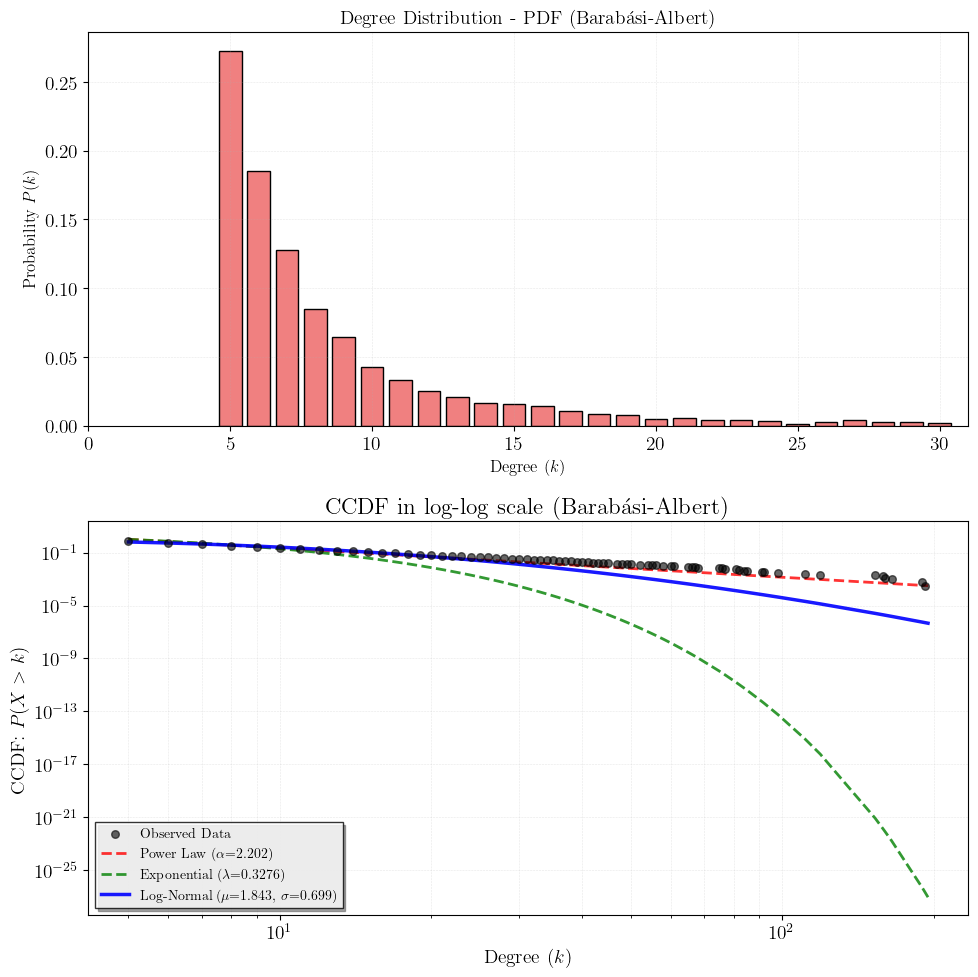

In [21]:
# Calculate BA parameters
# For Barabási-Albert, we need to determine m (number of edges to attach from new node)
# m can be estimated from average degree
num_nodes = G_giant.number_of_nodes()
num_edges = G_giant.number_of_edges()
avg_degree = 2 * num_edges / num_nodes
m = int(avg_degree / 2)  # Typical choice for BA model

print(f"Barabási-Albert Model Parameters:")
print(f"  Number of nodes: {num_nodes}")
print(f"  Number of edges: {num_edges}")
print(f"  Average degree: {avg_degree:.3f}")
print(f"  m (edges per new node): {m}")

# Generate 10 BA graphs
ba_graphs = []
for i in range(10):
    G_ba = nx.barabasi_albert_graph(num_nodes, m, seed=i)
    ba_graphs.append(G_ba)

# Use first BA graph for PDF/CCDF analysis
G_ba_sample = ba_graphs[0]

# ============================================================================
# CALCULATE DEGREES FOR G_BA
# ============================================================================

degrees = [G_ba_sample.degree(n) for n in G_ba_sample.nodes()]
degrees_array = np.array(degrees)

print(f"\nDEGREE STATISTICS (Barabási-Albert Graph 1):")
print(f"  Minimum degree:        {np.min(degrees)}")
print(f"  Maximum degree:        {np.max(degrees)}")
print(f"  Average degree:        {np.mean(degrees):.3f}")
print(f"  Median degree:         {np.median(degrees):.1f}")
print(f"  Standard deviation:    {np.std(degrees):.3f}")
print(f"  Total nodes:           {len(degrees)}")

# ============================================================================
# AVERAGE STATISTICS FOR BA GRAPHS
# ============================================================================

# Average statistics of the 10 BA graphs
avg_nodes = sum(g.number_of_nodes() for g in ba_graphs) / 10
avg_edges = sum(g.number_of_edges() for g in ba_graphs) / 10
avg_density = sum(nx.density(g) for g in ba_graphs) / 10
avg_clustering = sum(nx.average_clustering(g) for g in ba_graphs) / 10
avg_shortest_path_length = sum(nx.average_shortest_path_length(g) if nx.is_connected(g) else 0 for g in ba_graphs) / 10
avg_effective_diameter = sum(np.percentile([d for source in g.nodes() for target, d in nx.single_source_shortest_path_length(g, source).items() if source != target], 90) for g in ba_graphs) / 10

print(f"\n{'='*50}")
print(f"Statistics for the 10 BA networks:")
print(f"  Average nodes: {avg_nodes:.0f}")
print(f"  Average edges: {avg_edges:.0f}")
print(f"  Average density: {avg_density:.6f}")
print(f"  Average clustering coefficient: {avg_clustering:.6f}")
print(f"  Average shortest path length (if connected): {avg_shortest_path_length:.6f}")
print(f"  Average effective diameter (90th percentile): {avg_effective_diameter:.6f}")

print(f"\nComparison with G_giant:")
print(f"  G_giant nodes: {num_nodes}")
print(f"  G_giant edges: {num_edges}")
print(f"  G_giant density: {nx.density(G_giant):.6f}")
print(f"  G_giant average clustering coefficient: {nx.average_clustering(G_giant):.6f}")
print(f"  G_giant average shortest path length (if connected): {nx.average_shortest_path_length(G_giant) if nx.is_connected(G_giant) else 'N/A (not connected)'}")

# ============================================================================
# PDF AND CCDF FOR BA
# ============================================================================

# PDF
unique_degrees, counts = np.unique(degrees, return_counts=True)
pdf = counts / len(degrees)

# CCDF
ccdf = []
for k in unique_degrees:
    count_greater = np.sum(degrees_array > k)
    ccdf.append(count_greater / len(degrees_array))
ccdf = np.array(ccdf)

print(f"\nUnique degrees: {len(unique_degrees)}")
print(f"\nFirst 10 degrees and their frequencies:")
print(f"{'Degree':<10} {'Frequency':<15} {'Percentage':<15}")
print("-" * 40)
for i in range(min(10, len(unique_degrees))):
    print(f"{unique_degrees[i]:<10} {counts[i]:<15} {pdf[i]*100:>6.2f}%")

# ============================================================================
# DISTRIBUTION FUNCTIONS
# ============================================================================

def power_law_ccdf(k, alpha, k_min):
    """Power law: P(X > k) = (k/k_min)^(-alpha)"""
    return (k / k_min) ** (-alpha)

def exponential_ccdf(k, lambda_param, k_min):
    """Exponential: P(X > k) = exp(-lambda*(k-k_min))"""
    return np.exp(-lambda_param * (k - k_min))

def lognormal_ccdf(k, mu, sigma, k_min):
    """Log-normal: P(X > k) for log-normal distribution"""
    return 1 - stats.lognorm.cdf(k, sigma, scale=np.exp(mu))

# Prepare data for fitting
k_min = np.min(unique_degrees)
ccdf_data = ccdf[unique_degrees >= k_min]
degrees_fit = unique_degrees[unique_degrees >= k_min]

# ============================================================================
# FIT 1: POWER LAW
# ============================================================================

print(f"\n{'='*80}")
print("FITTING DISTRIBUTIONS (Barabási-Albert Network)")
print(f"{'='*80}\n")

print("1. POWER LAW")
print("-" * 50)

try:
    popt_pl, _ = curve_fit(
        power_law_ccdf, 
        degrees_fit, 
        ccdf_data,
        p0=[2.5, k_min],
        maxfev=10000,
        bounds=([1.5, k_min], [5, k_min+1])
    )
    alpha_fit, k_min_fit = popt_pl
    y_pred_pl = power_law_ccdf(degrees_fit, *popt_pl)
    ss_res_pl = np.sum((ccdf_data - y_pred_pl) ** 2)
    ss_tot = np.sum((ccdf_data - np.mean(ccdf_data)) ** 2)
    r2_pl = 1 - (ss_res_pl / ss_tot) if ss_tot != 0 else 0
    ks_stat_pl = np.max(np.abs(ccdf_data - y_pred_pl))
    
    print(f"  Parameters found:")
    print(f"    - α (exponent): {alpha_fit:.4f}")
    print(f"    - k_min: {k_min_fit:.1f}")
    print(f"  Goodness of fit:")
    print(f"    - R²: {r2_pl:.6f}")
    print(f"    - KS statistic: {ks_stat_pl:.6f}")
    
except Exception as e:
    print(f"  Error: {e}")
    popt_pl = None
    r2_pl = -1
    ks_stat_pl = 999

# ============================================================================
# FIT 2: EXPONENTIAL
# ============================================================================

print("\n2. EXPONENTIAL")
print("-" * 50)

try:
    popt_exp, _ = curve_fit(
        exponential_ccdf,
        degrees_fit,
        ccdf_data,
        p0=[0.1, k_min],
        maxfev=10000,
        bounds=([0.01, k_min], [1, k_min+1])
    )
    lambda_fit, k_min_exp = popt_exp
    y_pred_exp = exponential_ccdf(degrees_fit, *popt_exp)
    ss_res_exp = np.sum((ccdf_data - y_pred_exp) ** 2)
    r2_exp = 1 - (ss_res_exp / ss_tot) if ss_tot != 0 else 0
    ks_stat_exp = np.max(np.abs(ccdf_data - y_pred_exp))
    
    print(f"  Parameters found:")
    print(f"    - λ (lambda): {lambda_fit:.6f}")
    print(f"    - k_min: {k_min_exp:.1f}")
    print(f"  Goodness of fit:")
    print(f"    - R²: {r2_exp:.6f}")
    print(f"    - KS statistic: {ks_stat_exp:.6f}")
    
except Exception as e:
    print(f"  Error: {e}")
    popt_exp = None
    r2_exp = -1
    ks_stat_exp = 999

# ============================================================================
# FIT 3: LOG-NORMAL
# ============================================================================

print("\n3. LOG-NORMAL")
print("-" * 50)

try:
    popt_ln, _ = curve_fit(
        lognormal_ccdf,
        degrees_fit,
        ccdf_data,
        p0=[2, 1, k_min],
        maxfev=10000,
        bounds=([0, 0.1, k_min], [5, 3, k_min+1])
    )
    mu_fit, sigma_fit, k_min_ln = popt_ln
    y_pred_ln = lognormal_ccdf(degrees_fit, *popt_ln)
    ss_res_ln = np.sum((ccdf_data - y_pred_ln) ** 2)
    r2_ln = 1 - (ss_res_ln / ss_tot) if ss_tot != 0 else 0
    ks_stat_ln = np.max(np.abs(ccdf_data - y_pred_ln))
    
    print(f"  Parameters found:")
    print(f"    - μ (mean): {mu_fit:.4f}")
    print(f"    - σ (standard deviation): {sigma_fit:.4f}")
    print(f"    - k_min: {k_min_ln:.1f}")
    print(f"  Goodness of fit:")
    print(f"    - R²: {r2_ln:.6f}")
    print(f"    - KS statistic: {ks_stat_ln:.6f}")
    
except Exception as e:
    print(f"  Error: {e}")
    popt_ln = None
    r2_ln = -1
    ks_stat_ln = 999

# ============================================================================
# COMPARISON
# ============================================================================

print(f"\n{'='*80}")
print("COMPARISON OF GOODNESS OF FIT")
print(f"{'='*80}\n")

results = pd.DataFrame({
    'Distribution': ['Power Law', 'Exponential', 'Log-Normal'],
    'R²': [r2_pl, r2_exp, r2_ln],
    'KS statistic': [ks_stat_pl, ks_stat_exp, ks_stat_ln]
})

print(results.to_string(index=False))

best_idx = results['R²'].idxmax()
best_fit = results.loc[best_idx, 'Distribution']
best_r2 = results.loc[best_idx, 'R²']

print(f"\nFINAL RESULT: {best_fit} (R² = {best_r2:.6f})")

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# SUBPLOT 1: PDF
max_degree_pdf = 30
mask_pdf = unique_degrees <= max_degree_pdf
ax1 = axes[0]
ax1.bar(unique_degrees[mask_pdf], pdf[mask_pdf], color='lightcoral', edgecolor='black')
ax1.set_xlabel('Degree $(k)$', fontsize=12, fontweight='bold')
ax1.set_ylabel('Probability $P(k)$', fontsize=12, fontweight='bold')
ax1.set_title('Degree Distribution - PDF (Barabási-Albert)', fontsize=14, fontweight='bold')
ax1.set_xlim(0, max_degree_pdf + 1)
ax1.grid(True, alpha=0.3)

# SUBPLOT 2: CCDF
ax2 = axes[1]
ax2.scatter(degrees_fit, ccdf_data, s=30, alpha=0.6, color='black', 
            label='Observed Data', zorder=5)

if popt_pl is not None:
    ax2.plot(degrees_fit, power_law_ccdf(degrees_fit, *popt_pl), 
             'r--', linewidth=2, alpha=0.8, label=f'Power Law ($\\alpha$={alpha_fit:.3f})')

if popt_exp is not None:
    ax2.plot(degrees_fit, exponential_ccdf(degrees_fit, *popt_exp), 
             'g--', linewidth=2, alpha=0.8, label=f'Exponential ($\\lambda$={lambda_fit:.4f})')

if popt_ln is not None:
    ax2.plot(degrees_fit, lognormal_ccdf(degrees_fit, *popt_ln), 
             'b-', linewidth=2.5, alpha=0.9, label=f'Log-Normal ($\\mu$={mu_fit:.3f}, $\\sigma$={sigma_fit:.3f})')

ax2.set_xlabel('Degree $(k)$')
ax2.set_ylabel('CCDF: $P(X > k)$')
ax2.set_title('CCDF in log-log scale (Barabási-Albert)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('../results/figures/degree_distribution_analysis_ba.pdf', bbox_inches='tight')
plt.show()


DEGREE STATISTICS (Average of 10 Barabási-Albert Graphs):
  Minimum degree:        4
  Maximum degree:        282
  Average degree:        9.984
  Median degree:         7.0
  Standard deviation:    11.696

FITTING DISTRIBUTIONS (Average BA Network)

1. POWER LAW
--------------------------------------------------
  Parameters found:
    - α (exponent): 1.7047
    - k_min: 4.2
  Goodness of fit:
    - R²: 0.999739
    - KS statistic: 0.010574

2. EXPONENTIAL
--------------------------------------------------
  Parameters found:
    - λ (lambda): 0.245296
    - k_min: 4.0
  Goodness of fit:
    - R²: 0.973023
    - KS statistic: 0.074466

3. LOG-NORMAL
--------------------------------------------------
  Parameters found:
    - μ (mean): 1.9171
    - σ (standard deviation): 0.5902
    - k_min: 4.0
  Goodness of fit:
    - R²: 0.967382
    - KS statistic: 0.184201

COMPARISON OF GOODNESS OF FIT

Distribution       R²  KS statistic
   Power Law 0.999739      0.010574
 Exponential 0.973023

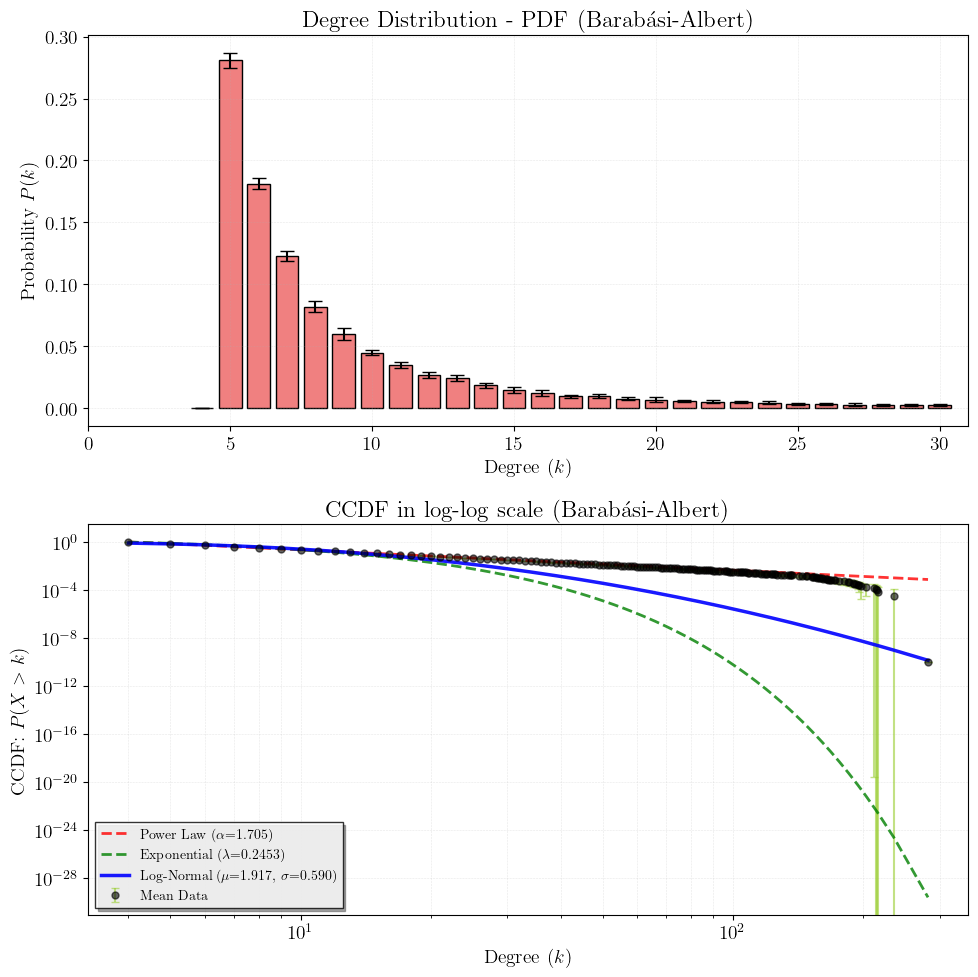

In [17]:
# ============================================================================
# CALCULATE DEGREES FOR ALL 10 BA GRAPHS
# ============================================================================

all_degrees = []
for i, G_ba in enumerate(ba_graphs):
    degrees = [G_ba.degree(n) for n in G_ba.nodes()]
    all_degrees.append(degrees)

all_degrees = np.array(all_degrees)

# Calculate mean and std for each degree value across all 10 networks
unique_degrees_all = np.unique(np.concatenate(all_degrees))

# Calculate PDF and CCDF statistics across all networks
pdf_mean = []
pdf_std = []
ccdf_mean = []
ccdf_std = []

for k in unique_degrees_all:
    pdf_values = []
    ccdf_values = []
    
    for degrees in all_degrees:
        degrees_array = np.array(degrees)
        
        # PDF
        count = np.sum(degrees_array == k)
        pdf_val = count / len(degrees_array)
        pdf_values.append(pdf_val)
        
        # CCDF
        count_greater = np.sum(degrees_array > k)
        ccdf_val = count_greater / len(degrees_array)
        ccdf_values.append(ccdf_val)
    
    pdf_mean.append(np.mean(pdf_values))
    pdf_std.append(np.std(pdf_values))
    ccdf_mean.append(np.mean(ccdf_values))
    ccdf_std.append(np.std(ccdf_values))

pdf_mean = np.array(pdf_mean)
pdf_std = np.array(pdf_std)
ccdf_mean = np.array(ccdf_mean)
ccdf_std = np.array(ccdf_std)

print(f"\nDEGREE STATISTICS (Average of 10 Barabási-Albert Graphs):")
print(f"  Minimum degree:        {np.min(unique_degrees_all)}")
print(f"  Maximum degree:        {np.max(unique_degrees_all)}")
print(f"  Average degree:        {np.mean(np.concatenate(all_degrees)):.3f}")
print(f"  Median degree:         {np.median(np.concatenate(all_degrees)):.1f}")
print(f"  Standard deviation:    {np.std(np.concatenate(all_degrees)):.3f}")

# Filter data to avoid divide by zero and invalid operations
k_min = np.min(unique_degrees_all)
ccdf_data = ccdf_mean[unique_degrees_all >= k_min]
degrees_fit = unique_degrees_all[unique_degrees_all >= k_min]

# Add small epsilon to avoid log(0) and divide by zero
epsilon = 1e-10
ccdf_data = np.clip(ccdf_data, epsilon, 1.0)

# Calculate upper and lower bounds for CCDF error bars
ccdf_upper = ccdf_mean + ccdf_std
ccdf_lower = np.maximum(ccdf_mean - ccdf_std, epsilon)

# ============================================================================
# DISTRIBUTION FUNCTIONS
# ============================================================================

def power_law_ccdf(k, alpha, k_min):
    """Power law: P(X > k) = (k/k_min)^(-alpha)"""
    k_safe = np.maximum(k, k_min + epsilon)
    return np.power(k_safe / k_min, -alpha)

def exponential_ccdf(k, lambda_param, k_min):
    """Exponential: P(X > k) = exp(-lambda*(k-k_min))"""
    return np.exp(-lambda_param * np.maximum(k - k_min, 0))

def lognormal_ccdf(k, mu, sigma, k_min):
    """Log-normal: P(X > k) for log-normal distribution"""
    k_safe = np.maximum(k, k_min + epsilon)
    return 1 - stats.lognorm.cdf(k_safe, sigma, scale=np.exp(mu))

# ============================================================================
# FIT 1: POWER LAW
# ============================================================================

print(f"\n{'='*80}")
print("FITTING DISTRIBUTIONS (Average BA Network)")
print(f"{'='*80}\n")

print("1. POWER LAW")
print("-" * 50)

try:
    popt_pl, _ = curve_fit(
        power_law_ccdf, 
        degrees_fit, 
        ccdf_data,
        p0=[2.5, k_min],
        maxfev=10000,
        bounds=([1.5, k_min], [5, k_min+1])
    )
    alpha_fit, k_min_fit = popt_pl
    y_pred_pl = power_law_ccdf(degrees_fit, *popt_pl)
    ss_res_pl = np.sum((ccdf_data - y_pred_pl) ** 2)
    ss_tot = np.sum((ccdf_data - np.mean(ccdf_data)) ** 2)
    r2_pl = 1 - (ss_res_pl / ss_tot) if ss_tot != 0 else 0
    ks_stat_pl = np.max(np.abs(ccdf_data - y_pred_pl))
    
    print(f"  Parameters found:")
    print(f"    - α (exponent): {alpha_fit:.4f}")
    print(f"    - k_min: {k_min_fit:.1f}")
    print(f"  Goodness of fit:")
    print(f"    - R²: {r2_pl:.6f}")
    print(f"    - KS statistic: {ks_stat_pl:.6f}")
    
except Exception as e:
    print(f"  Error: {e}")
    popt_pl = None
    r2_pl = -1
    ks_stat_pl = 999

# ============================================================================
# FIT 2: EXPONENTIAL
# ============================================================================

print("\n2. EXPONENTIAL")
print("-" * 50)

try:
    popt_exp, _ = curve_fit(
        exponential_ccdf,
        degrees_fit,
        ccdf_data,
        p0=[0.1, k_min],
        maxfev=10000,
        bounds=([0.01, k_min], [1, k_min+1])
    )
    lambda_fit, k_min_exp = popt_exp
    y_pred_exp = exponential_ccdf(degrees_fit, *popt_exp)
    ss_res_exp = np.sum((ccdf_data - y_pred_exp) ** 2)
    r2_exp = 1 - (ss_res_exp / ss_tot) if ss_tot != 0 else 0
    ks_stat_exp = np.max(np.abs(ccdf_data - y_pred_exp))
    
    print(f"  Parameters found:")
    print(f"    - λ (lambda): {lambda_fit:.6f}")
    print(f"    - k_min: {k_min_exp:.1f}")
    print(f"  Goodness of fit:")
    print(f"    - R²: {r2_exp:.6f}")
    print(f"    - KS statistic: {ks_stat_exp:.6f}")
    
except Exception as e:
    print(f"  Error: {e}")
    popt_exp = None
    r2_exp = -1
    ks_stat_exp = 999

# ============================================================================
# FIT 3: LOG-NORMAL
# ============================================================================

print("\n3. LOG-NORMAL")
print("-" * 50)

try:
    popt_ln, _ = curve_fit(
        lognormal_ccdf,
        degrees_fit,
        ccdf_data,
        p0=[2, 1, k_min],
        maxfev=10000,
        bounds=([0, 0.1, k_min], [5, 3, k_min+1])
    )
    mu_fit, sigma_fit, k_min_ln = popt_ln
    y_pred_ln = lognormal_ccdf(degrees_fit, *popt_ln)
    ss_res_ln = np.sum((ccdf_data - y_pred_ln) ** 2)
    r2_ln = 1 - (ss_res_ln / ss_tot) if ss_tot != 0 else 0
    ks_stat_ln = np.max(np.abs(ccdf_data - y_pred_ln))
    
    print(f"  Parameters found:")
    print(f"    - μ (mean): {mu_fit:.4f}")
    print(f"    - σ (standard deviation): {sigma_fit:.4f}")
    print(f"    - k_min: {k_min_ln:.1f}")
    print(f"  Goodness of fit:")
    print(f"    - R²: {r2_ln:.6f}")
    print(f"    - KS statistic: {ks_stat_ln:.6f}")
    
except Exception as e:
    print(f"  Error: {e}")
    popt_ln = None
    r2_ln = -1
    ks_stat_ln = 999

# ============================================================================
# COMPARISON
# ============================================================================

print(f"\n{'='*80}")
print("COMPARISON OF GOODNESS OF FIT")
print(f"{'='*80}\n")

results = pd.DataFrame({
    'Distribution': ['Power Law', 'Exponential', 'Log-Normal'],
    'R²': [r2_pl, r2_exp, r2_ln],
    'KS statistic': [ks_stat_pl, ks_stat_exp, ks_stat_ln]
})

print(results.to_string(index=False))

best_idx = results['R²'].idxmax()
best_fit = results.loc[best_idx, 'Distribution']
best_r2 = results.loc[best_idx, 'R²']

print(f"\nFINAL RESULT: {best_fit} (R² = {best_r2:.6f})")

# ============================================================================
# VISUALIZATION WITH ERROR BARS
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# SUBPLOT 1: PDF WITH ERROR BARS
max_degree_pdf = 30
mask_pdf = unique_degrees_all <= max_degree_pdf
ax1 = axes[0]
ax1.bar(unique_degrees_all[mask_pdf], pdf_mean[mask_pdf], 
        yerr=pdf_std[mask_pdf], color='lightcoral', edgecolor='black', capsize=5)
ax1.set_xlabel('Degree $(k)$')
ax1.set_ylabel('Probability $P(k)$')
ax1.set_title('Degree Distribution - PDF (Barabási-Albert)')
ax1.set_xlim(0, max_degree_pdf + 1)
ax1.grid(True, alpha=0.3)

# SUBPLOT 2: CCDF WITH ERROR BARS
ax2 = axes[1]

# Get the indices that match degrees_fit
mask_fit = unique_degrees_all >= k_min

# Extract error bars for only the fitted degrees
ccdf_yerr = ccdf_std[mask_fit]

# Mean data with error bars
ax2.errorbar(degrees_fit, ccdf_data, yerr=ccdf_yerr, fmt='o', 
             markersize=5, alpha=0.6, 
             color='black',           # Color de los puntos
             ecolor='yellowgreen',    # Color de las barras de error
             label='Mean Data', capsize=3, capthick=1)

# Fits
if popt_pl is not None:
    ax2.plot(degrees_fit, power_law_ccdf(degrees_fit, *popt_pl), 
             'r--', linewidth=2, alpha=0.8, label=f'Power Law ($\\alpha$={alpha_fit:.3f})')

if popt_exp is not None:
    ax2.plot(degrees_fit, exponential_ccdf(degrees_fit, *popt_exp), 
             'g--', linewidth=2, alpha=0.8, label=f'Exponential ($\\lambda$={lambda_fit:.4f})')

if popt_ln is not None:
    ax2.plot(degrees_fit, lognormal_ccdf(degrees_fit, *popt_ln), 
             'b-', linewidth=2.5, alpha=0.9, label=f'Log-Normal ($\\mu$={mu_fit:.3f}, $\\sigma$={sigma_fit:.3f})')

ax2.set_xlabel('Degree $(k)$')
ax2.set_ylabel('CCDF: $P(X > k)$')
ax2.set_title('CCDF in log-log scale (Barabási-Albert)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('../results/figures/degree_distribution_analysis_ba_with_errors.pdf', bbox_inches='tight')
plt.show()

---

## Communities

In [34]:
from networkx.algorithms import community

print("="*80)
print("COMMUNITY DETECTION - LOUVAIN METHOD")
print("="*80)

# ============================================================================
# 1. LOUVAIN ON G_GIANT (Real airport network)
# ============================================================================

print("\n1. ANALYZING G_GIANT (Real Airport Network)")
print("-" * 80)

# Detect communities using Louvain
communities_giant = community.greedy_modularity_communities(G_giant)
modularity_giant = community.modularity(G_giant, communities_giant)

print(f"\nNumber of communities detected: {len(communities_giant)}")
print(f"Modularity score: {modularity_giant:.6f}")

# Analyze each community
print(f"\nCommunity sizes:")
community_sizes_giant = []
for i, comm in enumerate(communities_giant):
    size = len(comm)
    community_sizes_giant.append(size)
    print(f"  Community {i+1}: {size} nodes ({100*size/G_giant.number_of_nodes():.2f}%)")

# Get top airports in each community (by degree within the community)
print(f"\nTop 5 airports per community (by degree):")
for i, comm in enumerate(communities_giant):
    # Calculate degrees within community
    subgraph = G_giant.subgraph(comm)
    degrees_in_comm = dict(subgraph.degree())
    top_nodes = sorted(degrees_in_comm.items(), key=lambda x: x[1], reverse=True)[:5]
    
    print(f"\n  Community {i+1}:")
    for node_id, degree in top_nodes:
        node_attrs = G_giant.nodes[node_id]
        name = node_attrs.get('name', 'Unknown')
        iata = node_attrs.get('IATA', 'N/A')
        country = node_attrs.get('country', 'Unknown')
        print(f"    - {iata}: {name} ({country}) - degree: {degree}")

# ============================================================================
# 2. LOUVAIN ON G_ER_SAMPLE (Erdős-Rényi random network)
# ============================================================================

print("\n" + "="*80)
print("2. ANALYZING G_ER_SAMPLE (Erdős-Rényi Network)")
print("-" * 80)

communities_er = community.greedy_modularity_communities(G_er_sample)
modularity_er = community.modularity(G_er_sample, communities_er)

print(f"\nNumber of communities detected: {len(communities_er)}")
print(f"Modularity score: {modularity_er:.6f}")

print(f"\nCommunity sizes:")
community_sizes_er = []
for i, comm in enumerate(communities_er):
    size = len(comm)
    community_sizes_er.append(size)
    print(f"  Community {i+1}: {size} nodes ({100*size/G_er_sample.number_of_nodes():.2f}%)")

# ============================================================================
# 3. LOUVAIN ON G_BA_SAMPLE (Barabási-Albert scale-free network)
# ============================================================================

print("\n" + "="*80)
print("3. ANALYZING G_BA_SAMPLE (Barabási-Albert Network)")
print("-" * 80)

communities_ba = community.greedy_modularity_communities(G_ba_sample)
modularity_ba = community.modularity(G_ba_sample, communities_ba)

print(f"\nNumber of communities detected: {len(communities_ba)}")
print(f"Modularity score: {modularity_ba:.6f}")

print(f"\nCommunity sizes:")
community_sizes_ba = []
for i, comm in enumerate(communities_ba):
    size = len(comm)
    community_sizes_ba.append(size)
    print(f"  Community {i+1}: {size} nodes ({100*size/G_ba_sample.number_of_nodes():.2f}%)")

# ============================================================================
# 4. COMPARISON OF RESULTS
# ============================================================================

print("\n" + "="*80)
print("COMPARISON OF COMMUNITY STRUCTURE ACROSS NETWORKS")
print("="*80)

comparison = pd.DataFrame({
    'Network': ['G_giant (Real)', 'G_ER (Random)', 'G_BA (Scale-free)'],
    'Nodes': [G_giant.number_of_nodes(), G_er_sample.number_of_nodes(), G_ba_sample.number_of_nodes()],
    'Edges': [G_giant.number_of_edges(), G_er_sample.number_of_edges(), G_ba_sample.number_of_edges()],
    'Communities': [len(communities_giant), len(communities_er), len(communities_ba)],
    'Modularity': [modularity_giant, modularity_er, modularity_ba],
    'Avg Community Size': [np.mean(community_sizes_giant), np.mean(community_sizes_er), np.mean(community_sizes_ba)]
})

print("\n" + comparison.to_string(index=False))

# ============================================================================
# 5. INTERPRETATION
# ============================================================================

print("\n" + "="*80)
print("INTERPRETATION OF RESULTS")
print("="*80)

print("\n1. G_GIANT (Real Airport Network):")
print(f"   - Modularity: {modularity_giant:.6f}")
if modularity_giant > 0.5:
    print(f"   ✓ Strong community structure detected")
elif modularity_giant > 0.3:
    print(f"   ✓ Moderate community structure detected")
else:
    print(f"   - Weak community structure detected")

print(f"   - Number of communities: {len(communities_giant)}")
print(f"   - Interpretation: The real airport network shows {'strong' if modularity_giant > 0.4 else 'moderate' if modularity_giant > 0.2 else 'weak'} regional clustering.")
print(f"     Communities likely represent geographic regions or hub groupings.")

print("\n2. G_ER_SAMPLE (Erdős-Rényi Random Network):")
print(f"   - Modularity: {modularity_er:.6f}")
if modularity_er > 0.3:
    print(f"   ✓ Some community structure (unexpected for random graph)")
else:
    print(f"   - Very weak community structure (expected for random graph)")

print(f"   - Number of communities: {len(communities_er)}")
print(f"   - Interpretation: Random networks typically have weak modularity (~0.1-0.2).")
print(f"     If modularity is higher, it's due to random fluctuations in edge placement.")

print("\n3. G_BA_SAMPLE (Barabási-Albert Scale-Free Network):")
print(f"   - Modularity: {modularity_ba:.6f}")
if modularity_ba > 0.3:
    print(f"   ✓ Some community structure detected")
else:
    print(f"   - Weak community structure detected")

print(f"   - Number of communities: {len(communities_ba)}")
print(f"   - Interpretation: Scale-free networks from BA model typically have weak modularity")
print(f"     because they're built by preferential attachment (hubs connect to everything).")

# ============================================================================
# 6. SAVE RESULTS TO CSV
# ============================================================================

comparison.to_csv('../results/tables/community_detection_comparison.csv', index=False)

# Save G_giant community assignments
community_assignment = {}
for i, comm in enumerate(communities_giant):
    for node in comm:
        community_assignment[node] = i

airport_communities = []
for node_id, comm_id in community_assignment.items():
    node_attrs = G_giant.nodes[node_id]
    airport_communities.append({
        'airport_id': node_id,
        'name': node_attrs.get('name', 'Unknown'),
        'IATA': node_attrs.get('IATA', 'N/A'),
        'city': node_attrs.get('city', 'Unknown'),
        'country': node_attrs.get('country', 'Unknown'),
        'degree': G_giant.degree(node_id),
        'community': comm_id
    })

df_communities = pd.DataFrame(airport_communities)
df_communities = df_communities.sort_values(['community', 'degree'], ascending=[True, False])
df_communities.to_hdf('../results/tables/airport_communities_giant.h5', key='df', mode='w')

COMMUNITY DETECTION - LOUVAIN METHOD

1. ANALYZING G_GIANT (Real Airport Network)
--------------------------------------------------------------------------------

Number of communities detected: 42
Modularity score: 0.597890

Community sizes:
  Community 1: 963 nodes (30.21%)
  Community 2: 893 nodes (28.01%)
  Community 3: 720 nodes (22.58%)
  Community 4: 131 nodes (4.11%)
  Community 5: 47 nodes (1.47%)
  Community 6: 43 nodes (1.35%)
  Community 7: 39 nodes (1.22%)
  Community 8: 39 nodes (1.22%)
  Community 9: 34 nodes (1.07%)
  Community 10: 24 nodes (0.75%)
  Community 11: 21 nodes (0.66%)
  Community 12: 20 nodes (0.63%)
  Community 13: 19 nodes (0.60%)
  Community 14: 15 nodes (0.47%)
  Community 15: 15 nodes (0.47%)
  Community 16: 14 nodes (0.44%)
  Community 17: 13 nodes (0.41%)
  Community 18: 12 nodes (0.38%)
  Community 19: 11 nodes (0.35%)
  Community 20: 10 nodes (0.31%)
  Community 21: 9 nodes (0.28%)
  Community 22: 8 nodes (0.25%)
  Community 23: 8 nodes (0.25%)
  

In [35]:
df_communities

,airport_id,name,IATA,city,country,degree,community
689,3364.0,Beijing Capital International Airport,PEK,Beijing,China,205,0
128,2188.0,Dubai International Airport,DXB,Dubai,United Arab Emirates,185,0
738,3406.0,Shanghai Pudong International Airport,PVG,Shanghai,China,152,0
694,3370.0,Guangzhou Baiyun International Airport,CAN,Guangzhou,China,146,0
491,3077.0,Hong Kong International Airport,HKG,Hong Kong,Hong Kong,133,0
...,...,...,...,...,...,...,...
3182,730.0,Arvidsjaur Airport,AJR,Arvidsjaur,Sweden,1,39
3184,1136.0,Aswan International Airport,ASW,Aswan,Egypt,3,40
3185,1127.0,Abu Simbel Airport,ABS,Abu Simbel,Egypt,1,40
3186,729.0,Vilhelmina Airport,VHM,Vilhelmina,Sweden,2,41


In [36]:
community_data = {}

for comm_id in df_communities['community'].unique():
    # Filter airports from this community
    comm_airports = df_communities[df_communities['community'] == comm_id]
    
    # Get coordinates and data
    lats = []
    lons = []
    texts = []
    degrees = []
    
    for _, row in comm_airports.iterrows():
        node_id = row['airport_id']
        if node_id in valid_nodes:
            node_data = G_giant.nodes[node_id]
            lat = node_data.get('lat')
            lon = node_data.get('lon')
            
            if lat is not None and lon is not None and not (pd.isna(lat) or pd.isna(lon)):
                lats.append(lat)
                lons.append(lon)
                degrees.append(row['degree'])
                texts.append(f"{row['name']}<br>{row['city']}, {row['country']}<br>IATA: {row['IATA']}<br>Connections: {row['degree']}<br>Community: {comm_id}")
    
    community_data[comm_id] = {
        'lats': lats,
        'lons': lons,
        'texts': texts,
        'degrees': degrees,
        'size': len(lats)
    }

# Create figure with all communities as separate traces
fig = go.Figure()

# Add one trace per community (ordenados para coincidir con los botones)
for comm_id in sorted(community_data.keys()):
    data = community_data[comm_id]
    fig.add_trace(
        go.Scattergeo(
            lon=data['lons'],
            lat=data['lats'],
            mode='markers',
            marker=dict(
                size=[d/5 for d in data['degrees']],
                color=comm_id,
                colorscale='Viridis',
                line=dict(width=0.5, color='white'),
                showscale=False
            ),
            text=data['texts'],
            hoverinfo='text',
            name=f'Community {comm_id} ({data["size"]} airports)',
            visible=True  # todas visibles por defecto
        )
    )

# Create buttons for the dropdown
buttons = []
sorted_ids = sorted(community_data.keys())
for i, comm_id in enumerate(sorted_ids):
    visibility = [False] * len(sorted_ids)
    visibility[i] = True
    
    buttons.append(
        dict(
            label=f'Community {comm_id} ({community_data[comm_id]["size"]} airports)',
            method='update',
            args=[
                {'visible': visibility},
                {'title': f'Airport Network - Community {comm_id}<br>({community_data[comm_id]["size"]} airports)'}
            ]
        )
    )

# Add button to show all communities
buttons.insert(0, dict(
    label='All Communities',
    method='update',
    args=[
        {'visible': [True] * len(sorted_ids)},
        {'title': 'Airport Network - All Communities'}
    ]
))

# Configure layout with dropdown
fig.update_layout(
    title={
        'text': 'Airport Network - All Communities',
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 20}
    },
    showlegend=True,
    geo=dict(
        projection_type='natural earth',
        showland=True,
        landcolor='rgb(243, 243, 243)',
        coastlinecolor='rgb(204, 204, 204)',
        showocean=True,
        oceancolor='rgb(230, 245, 255)',
        showcountries=True,
        countrycolor='rgb(204, 204, 204)'
    ),
    updatemenus=[
        dict(
            buttons=buttons,
            direction='down',
            pad={'r': 10, 't': 10},
            showactive=True,
            active=0,  # "All Communities" seleccionado por defecto
            x=0.1,
            xanchor='left',
            y=1.15,
            yanchor='top'
        )
    ],
    height=700,
    width=1400
)

# Save and display
fig.write_html("../results/figures/airport_communities_interactive.html")
fig.write_html("../docs/airport_communities_interactive.html")
fig.write_image("../results/figures/airport_communities_interactive.pdf", width=1400, height=700)
fig.write_image("../docs/airport_communities_interactive.png", width=1400, height=700)
print(f"Interactive community map saved with {len(community_data)} communities")

fig.show()

Interactive community map saved with 42 communities


In [37]:
community_data = {}
sorted_communities = sorted(df_communities['community'].unique())

for comm_id in sorted_communities:
    # Filter airports in this community
    comm_airports = df_communities[df_communities['community'] == comm_id]
    
    # Get coordinates and data
    lats = []
    lons = []
    texts = []
    degrees = []
    
    for _, row in comm_airports.iterrows():
        node_id = row['airport_id']
        # Use the valid_nodes set we calculated before
        if node_id in valid_nodes:
            # Make sure to extract lat/lon from the graph or dataframedataframedataframe
            # Here we assume G_giant has the data, if not, use row if it has lat/lon
            if node_id in G_giant.nodes:
                node_data = G_giant.nodes[node_id]
                lat = node_data.get('lat')
                lon = node_data.get('lon')
                
                if lat is not None and lon is not None and not (pd.isna(lat) or pd.isna(lon)):
                    lats.append(lat)
                    lons.append(lon)
                    degrees.append(row['degree'])
                    # Formatted text
                    texts.append(f"<b>{row['name']}</b> ({row['IATA']})<br>{row['city']}, {row['country']}<br>Connections: {row['degree']}<br>Community: {comm_id}")
    
    community_data[comm_id] = {
        'lats': lats,
        'lons': lons,
        'texts': texts,
        'degrees': degrees,
        'size': len(lats)
    }

print(f"Prepared data for {len(community_data)} communities.")

# 2. FIGURE AND TRACES CREATION
# ---------------------------------------------------------
fig = go.Figure()

# Add one trace per community
# Use Plotly's cyclic color palette to differentiate communities
colorscale_list = ['#38bdf8', '#34d399', '#f472b6', '#a78bfa', '#fbbf24', '#f87171'] # Tailwind colors (Cyan, Emerald, Pink, Violet, Amber, Red)

for i, comm_id in enumerate(sorted_communities):
    data = community_data[comm_id]
    
    # Assign cyclic color
    color_idx = i % len(colorscale_list)
    comm_color = colorscale_list[color_idx]
    
    fig.add_trace(
        go.Scattergeo(
            lon=data['lons'],
            lat=data['lats'],
            mode='markers',
            marker=dict(
                size=[d/4 for d in data['degrees']], # Adjusted size
                color=comm_color, 
                line=dict(width=0.5, color='rgba(255,255,255,0.5)'),
                opacity=0.9
            ),
            text=data['texts'],
            hoverinfo='text',
            name=f'Comm {comm_id}',
            visible=True # All visible at start
        )
    )

# 3. DROPDOWN MENU CREATION
# ---------------------------------------------------------
buttons = []

# Option 1: "All Communities"
buttons.append(dict(
    label='All Communities',
    method='update',
    args=[
        {'visible': [True] * len(sorted_communities)},
        # Don't change Plotly's internal layout title, we use external HTML
        # but if you want to change something internal, do it here.it here.it here.
    ]
))

# Options per community
for i, comm_id in enumerate(sorted_communities):
    # Create visibility list (only True at index i)
    visibility = [False] * len(sorted_communities)
    visibility[i] = True
    
    buttons.append(
        dict(
            label=f'Community {comm_id} ({community_data[comm_id]["size"]} airports)',
            method='update',
            args=[
                {'visible': visibility}
            ]
        )
    )

# 4. "SLATE DARK" STYLE LAYOUT
# ---------------------------------------------------------
fig.update_layout(
    template="plotly_dark",
    margin={"r":0,"t":0,"l":0,"b":0},
    paper_bgcolor='#020617', 
    plot_bgcolor='#020617',
    showlegend=False, # Hide legend to clean up, we already have the dropdown
    
    geo=dict(
        projection_type='natural earth',
        showland=True,
        landcolor='#0f172a',      # Slate-900
        showocean=True,
        oceancolor='#020617',     # Slate-950
        showlakes=True,
        lakecolor='#020617',      # Fix white zones
        showrivers=False,
        showcountries=True,
        countrycolor='#1e293b',   # Slate-800
        coastlinecolor='#1e293b',
        showframe=False,
        bgcolor='#020617',
        fitbounds="locations"
    ),
    
    # Dropdown configuration
    updatemenus=[
        dict(
            buttons=buttons,
            direction='down',
            pad={'r': 10, 't': 10},
            showactive=True,
            x=0.05,
            xanchor='left',
            y=1.1,
            yanchor='top',
            bgcolor='#1e293b',     # Menu backgrounddd
            bordercolor='#38bdf8', # Cyan borderrr
            font=dict(color='#e2e8f0')
        )
    ],
    height=750,
)

png_output_path = "../docs/airport_communities_interactive.png"
os.makedirs(os.path.dirname(png_output_path), exist_ok=True)

fig.write_image(png_output_path, width=1920, height=1080, scale=2)
print(f"✅ Static PNG image saved at: {png_output_path}")

# Generate only the DIVIVIV
plot_div = fig.to_html(full_html=False, include_plotlyjs='cdn', config={'responsive': True, 'displayModeBar': False})


# 5. HTML TEMPLATE (Identical style)
# ---------------------------------------------------------
html_template = f"""
<!DOCTYPE html>
<html lang="en" class="scroll-smooth">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0"> 
    <title>Community Detection Analysis</title>
    <meta name="description" content="Community detection visualization of the Global Airport Network."> 
    <script src="https://cdn.tailwindcss.com"></script>
    <link rel="icon" href="data:image/svg+xml,<svg xmlns=%22http://www.w3.org/2000/svg%22 viewBox=%220 0 100 100%22><text y=%22.9em%22 font-size=%2290%22>✈️</text></svg>">
    
    <link rel="preconnect" href="https://fonts.googleapis.com"> 
    <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin> 
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;800&family=JetBrains+Mono:wght@400;700&display=swap" rel="stylesheet"> 
    <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.4.0/css/all.min.css"> 

    <script>
        tailwind.config = {{
            theme: {{
                extend: {{
                    fontFamily: {{
                        sans: ['Inter', 'sans-serif'],
                        mono: ['JetBrains Mono', 'monospace'],
                    }},
                    colors: {{
                        bg: '#020617', 
                        surface: '#0f172a',
                        accent: '#38bdf8',
                        accentHover: '#0ea5e9', 
                    }}
                }}
            }}
        }}
    </script>

    <style>
        body {{
            background-color: #020617;
            color: #94a3b8;
        }}
        .plotly-graph-div {{
            margin: auto;
            border-radius: 1rem;
            overflow: hidden;
            border: 1px solid rgba(255, 255, 255, 0.05);
            box-shadow: 0 25px 50px -12px rgba(0, 0, 0, 0.5);
        }}
        
        /* ESTILOS PARA EL DROPDOWN DE PLOTLY (Select) */
        /* El contenedor del dropdown */
        .updatemenu-container {{
            border: 1px solid #38bdf8 !important;
            border-radius: 0.375rem !important;
            background-color: #1e293b !important;
        }}
        
        /* El botón principal del dropdown */
        .updatemenu-button {{
            background-color: #1e293b !important;
        }}
        
        /* Texto del dropdown */
        .updatemenu-item-text {{
            fill: #e2e8f0 !important;
            font-family: 'Inter', sans-serif !important;
        }}
        
        /* Corrección para que no se vea blanco al interactuar */
        .updatemenu-item rect {{
            fill: #1e293b !important;
        }}
        .updatemenu-item rect:hover {{
            fill: #334155 !important;
        }}
        
    </style>
</head>
<body class="antialiased selection:bg-sky-500/30 flex flex-col min-h-screen"> 

    <nav class="fixed w-full z-50 border-b border-white/5 bg-[#020617]/90 backdrop-blur-xl"> 
        <div class="max-w-8xl mx-auto px-4 md:px-6 h-16 flex items-center justify-between"> 
            <div class="font-bold text-lg tracking-tight text-white flex items-center gap-2"> 
                <i class="fa-solid fa-circle-nodes text-accent"></i> 
                <span>Community <span class="text-slate-400">Structure</span></span> 
            </div> 
            <div> 
                <a href="index.html" class="text-sm font-medium text-slate-400 hover:text-white transition-colors flex items-center gap-2 px-4 py-2 rounded-lg hover:bg-white/5"> 
                    <i class="fa-solid fa-arrow-left"></i> Back to Home 
                </a> 
            </div> 
        </div> 
    </nav> 

    <main class="flex-grow pt-24 pb-12 container max-w-[95%] mx-auto px-2 md:px-4 flex flex-col items-center"> 
        <div class="text-center mb-8 max-w-2xl mx-auto"> 
            <h1 class="text-3xl md:text-4xl font-bold text-white mb-2">Network Communities</h1> 
            <p class="text-slate-400">
                Detected clusters within the global airport network using the Louvain algorithm.
                <span class="hidden md:inline">Use the dropdown menu to filter specific communities.</span>
            </p> 
        </div> 
        
        <div class="w-full relative z-0">
            {plot_div}
        </div>
    </main> 

    <footer class="border-t border-white/5 bg-[#020617] py-8 text-center text-slate-600 text-xs uppercase tracking-wider font-mono"> 
        <p>&copy; 2025 Global Airport Network Analysis</p> 
    </footer> 
</body>
</html>
"""

# Guardar
output_path = "../docs/airport_communities_interactive.html"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with open(output_path, "w", encoding="utf-8") as f:
    f.write(html_template)

print(f"✅ Community map saved at: {output_path}")

Prepared data for 42 communities.
✅ Static PNG image saved at: ../docs/airport_communities_interactive.png
✅ Community map saved at: ../docs/airport_communities_interactive.html



---
## Saving dataframe

In [38]:
# Create a base copy
export_df = df_communities.copy()

# Check if the dataframe 'df' with metrics exists
if 'df' in locals():
    # Ensure export_df has the correct index for the join
    if 'airport_id' in export_df.columns:
        export_df = export_df.set_index('airport_id')
    
    # TRICK TO AVOID THE ERROR:
    # Identify which columns in 'df' are NOT already in 'export_df'
    cols_to_add = df.columns.difference(export_df.columns)
    
    # Join only those new columns (avoids duplicating 'degree')
    export_df = export_df.join(df[cols_to_add])
    
    # Restore airport_id as a column
    export_df = export_df.reset_index()

# Select and rename columns for the final table
cols_to_keep = [
    'name', 'IATA', 'city', 'country', 'community', 
    'degree', 'degree centrality',  'betweenness', 'closeness', 'pagerank', 'eigenvector'
]

# Filter only the columns actually collected
final_cols = [c for c in cols_to_keep if c in export_df.columns]
table_df = export_df[final_cols].copy()

# Round decimals
table_df = table_df.round(4)

# Rename columns for nicer display (Capital initial)
table_df.columns = [c.capitalize() for c in table_df.columns]

# 2. HTML GENERATION (DARK / SLATE STYLE)
# ---------------------------------------------------------

# Generate HTML rows
table_rows = ""
for _, row in table_df.iterrows():
    table_rows += "<tr class='border-b border-slate-800 hover:bg-slate-900/50 transition-colors'>"
    for item in row:
        # Handle null/empty values so they don't show as "NaN"
        val = item if pd.notna(item) else ""
        table_rows += f"<td class='px-4 py-3 text-slate-400'>{val}</td>"
    table_rows += "</tr>"

# Generate HTML headers
table_headers = ""
for col in table_df.columns:
    table_headers += f"<th class='px-4 py-3 text-left text-xs font-bold text-sky-400 uppercase tracking-wider'>{col}</th>"

# Complete HTML template
html_content = f"""
<!DOCTYPE html>
<html lang=\"en\" class=\"scroll-smooth\">
<head>
    <meta charset=\"UTF-8\">
    <meta name=\"viewport\" content=\"width=device-width, initial-scale=1.0\"> 
    <title>Airport Network Data</title>
    <meta name=\"description\" content=\"Detailed data tables of the Global Airport Network.\"> 
    <script src=\"https://cdn.tailwindcss.com\"></script>
    <link rel="icon" href="data:image/svg+xml,<svg xmlns=%22http://www.w3.org/2000/svg%22 viewBox=%220 0 100 100%22><text y=%22.9em%22 font-size=%2290%22>✈️</text></svg>">

    
    <link rel=\"stylesheet\" href=\"https://cdn.datatables.net/1.13.6/css/jquery.dataTables.min.css\"> 
    
    <link rel=\"preconnect\" href=\"https://fonts.googleapis.com\"> 
    <link rel=\"preconnect\" href=\"https://fonts.gstatic.com\" crossorigin> 
    <link href=\"https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;800&family=JetBrains+Mono:wght@400;700&display=swap\" rel=\"stylesheet\"> 
    <link rel=\"stylesheet\" href=\"https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.4.0/css/all.min.css\"> 

    <script>
        tailwind.config = {{
            theme: {{
                extend: {{
                    fontFamily: {{
                        sans: ['Inter', 'sans-serif'],
                        mono: ['JetBrains Mono', 'monospace'],
                    }},
                    colors: {{
                        bg: '#020617', 
                        surface: '#0f172a',
                        accent: '#38bdf8',
                        accentHover: '#0ea5e9', 
                    }}
                }}
            }}
        }}
    </script>

    <style>
        body {{
            background-color: #020617;
            color: #94a3b8;
        }}
        /* DataTables Customization */
        .dataTables_wrapper .dataTables_length, 
        .dataTables_wrapper .dataTables_filter, 
        .dataTables_wrapper .dataTables_info, 
        .dataTables_wrapper .dataTables_processing, 
        .dataTables_wrapper .dataTables_paginate {{
            color: #94a3b8 !important;
            margin-bottom: 1rem;
            margin-top: 1rem;
        }}
        .dataTables_wrapper .dataTables_filter input {{
            background-color: #0f172a;
            border: 1px solid #1e293b;
            color: #e2e8f0;
            padding: 0.25rem 0.5rem;
            border-radius: 0.25rem;
            outline: none;
        }}
        .dataTables_wrapper .dataTables_filter input:focus {{
            border-color: #38bdf8;
        }}
        .dataTables_wrapper .dataTables_length select {{
            background-color: #0f172a;
            border: 1px solid #1e293b;
            color: #e2e8f0;
            padding: 0.25rem;
            border-radius: 0.25rem;
        }}
        /* Pagination Buttons */
        .dataTables_wrapper .dataTables_paginate .paginate_button {{
            color: #94a3b8 !important;
            border: 1px solid transparent !important;
            border-radius: 0.375rem;
        }}
        .dataTables_wrapper .dataTables_paginate .paginate_button.current {{
            background: #0f172a !important;
            border-color: #38bdf8 !important;
            color: #38bdf8 !important;
        }}
        .dataTables_wrapper .dataTables_paginate .paginate_button:hover {{
            background: #1e293b !important;
            color: #fff !important;
            border-color: #38bdf8 !important;
        }}
        table.dataTable tbody tr {{
            background-color: transparent !important;
        }}
        table.dataTable.no-footer {{
            border-bottom: 1px solid #1e293b;
        }}
    </style>
</head>
<body class=\"antialiased selection:bg-sky-500/30\"> 
    <nav class=\"fixed w-full z-50 border-b border-white/5 bg-[#020617]/80 backdrop-blur-xl\"> 
        <div class=\"max-w-8xl mx-auto px-4 md:px-6 h-16 flex items-center justify-between\"> 
            <div class=\"font-bold text-lg tracking-tight text-white flex items-center gap-2\"> 
                <i class=\"fa-solid fa-network-wired text-accent\"></i> 
                <span>Airport <span class=\"text-slate-400\">Data Explorer</span></span> 
            </div> 
            <div> 
                <a href=\"index.html\" class=\"text-sm font-medium text-slate-400 hover:text-white transition-colors flex items-center gap-2\"> 
                    <i class=\"fa-solid fa-arrow-left\"></i> Back to Home 
                </a> 
            </div> 
        </div> 
    </nav> 
    <main class=\"pt-24 pb-12 min-h-screen container max-w-8xl mx-auto px-4 md:px-6\"> 
        <div class=\"mb-8\"> 
            <h1 class=\"text-3xl md:text-4xl font-bold text-white mb-4\">Network Statistics & Data</h1> 
            <p class=\"text-slate-400 max-w-2xl\">Explore the full dataset of the Global Airport Network. Use the search box to find specific airports, or sort the columns to discover the most connected hubs (Degree), the best bridges (Betweenness), or community clusters.</p> 
        </div> 
        <div class=\"bg-slate-900/50 border border-white/5 rounded-2xl p-6 shadow-2xl overflow-hidden\"> 
            <div class=\"overflow-x-auto\"> 
                <table id=\"networkTable\" class=\"w-full text-left border-collapse\"> 
                    <thead> 
                        <tr class=\"bg-slate-900 border-b border-white/10\"> 
                            {table_headers} 
                        </tr> 
                    </thead> 
                    <tbody class=\"divide-y divide-slate-800/50 font-mono text-sm\"> 
                        {table_rows} 
                    </tbody> 
                </table> 
            </div> 
        </div> 
    </main> 
    <footer class=\"border-t border-white/5 bg-[#020617] py-8 text-center text-slate-600 text-xs uppercase tracking-wider font-mono\"> 
        <p>&copy; 2025 Global Airport Network Analysis</p> 
    </footer> 
    <script src=\"https://code.jquery.com/jquery-3.7.0.min.js\"></script> 
    <script src=\"https://cdn.datatables.net/1.13.6/js/jquery.dataTables.min.js\"></script> 
    <script> 
        $(document).ready(function() {{ 
            $('#networkTable').DataTable({{ 
                "pageLength": 25, 
                "order": [], // No initial forced order; use [[ 5, "desc" ]] for degree if desired
                "language": {{ 
                    "search": "_INPUT_", 
                    "searchPlaceholder": "Search airports, cities...", 
                    "lengthMenu": "Show _MENU_ entries", 
                    "info": "Showing _START_ to _END_ of _TOTAL_ airports" 
                }} 
            }}); 
        }}); 
    </script> 
</body>
</html>
"""

# 3. SAVE THE FILE
# ---------------------------------------------------------
output_path = "../docs/airport_data.html"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with open(output_path, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"✅ Interactive table successfully generated at: {output_path}")

✅ Interactive table successfully generated at: ../docs/airport_data.html
